In [1]:
!pip install open3d --q
!pip install plotly --q
!pip install pyntcloud --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 99.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 4.3 MB/s eta 0:00:0000:0100:01


# IMPORTING LIBRARIES

In [2]:

import numpy as np
import pandas as pd
import os
import time
import seaborn as sns
import xml.etree.ElementTree as ET
from pyntcloud import PyntCloud
import plotly.graph_objs as go
import matplotlib.pyplot as plt 
from plotly.offline import init_notebook_mode

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassMatthewsCorrCoef
import torch.optim as optim


import warnings
warnings.filterwarnings("ignore")

init_notebook_mode(connected=True)
%matplotlib inline

In [3]:
# Load Sample the PLY file
ply_file = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L002.ply"  # Replace with your file path
cloud = PyntCloud.from_file(ply_file)

# Print point cloud information
print(cloud)

# Convert to Pandas DataFrame
df = cloud.points
UTM_OFFSET = np.array([627285, 4841948, 0])
df[['x', 'y', 'z']] -= UTM_OFFSET
df.head()

PyntCloud
10283800 points with 7 scalar fields
0 faces in mesh
0 kdtrees
0 voxelgrids
Centroid: 627511.5987149103, 4842581.018657003, 136.91529315746322
Other attributes:
	 comments: <class 'list'>



,x,y,z,red,green,blue,scalar_Intensity,scalar_GPSTime,scalar_ScanAngleRank,scalar_Label
0,190.236000,718.848022,143.332993,98,88,27,2.0,324794.09375,29.0,3.0
1,190.694000,719.401001,143.031006,93,84,55,8.0,324794.15625,29.0,3.0
2,190.584000,719.551025,142.955002,99,82,54,6.0,324794.15625,29.0,3.0
3,190.387001,719.572998,142.873001,74,67,74,4.0,324794.15625,29.0,3.0
4,190.780998,719.507996,143.067001,87,55,44,8.0,324794.21875,27.0,3.0


# VISUALIZE SAMPLE DATA

In [4]:
# Load and parse XML file
def parse_color_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    # Namespace (if needed)
    ns = {'cc': 'http://www.cloudcompare.org/'}
    # Extract color steps
    color_steps = root.find('.//Data', ns)
    color_map = {}
    for step in color_steps.findall('step'):
        r = int(step.get('r'))
        g = int(step.get('g'))
        b = int(step.get('b'))
        pos = float(step.get('pos'))
        color_map[int(pos * 8)] = (r / 255.0, g / 255.0, b / 255.0)
    return color_map

# Map of labels to categories
label_categories = {0: 'Road', 1: 'Car', 2: 'Building', 3: 'Other'}

# Map of categories to colors (parsed from XML)
def get_category_colors(color_map):
    return {i: color_map[i] for i in label_categories.keys() if i in color_map}

# Example XML file path
xml_file = '/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/Colors.xml'
color_map = parse_color_xml(xml_file)
category_colors = get_category_colors(color_map)

In [5]:
# Load the PLY file
ply_file_1 = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L001.ply"
ply_file_2 = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L002.ply"
ply_file_3 = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L003.ply"
ply_file_4 = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L004.ply"

cloud_1 = PyntCloud.from_file(ply_file_1)
cloud_2 = PyntCloud.from_file(ply_file_2)
cloud_3 = PyntCloud.from_file(ply_file_3)
cloud_4 = PyntCloud.from_file(ply_file_4)

# Print point cloud information
print(cloud_1)
print(cloud_2)
print(cloud_3)
print(cloud_4)

# Convert to Pandas DataFrame
df_1 = cloud_1.points
df_2 = cloud_2.points
df_3 = cloud_3.points
df_4 = cloud_4.points


full_df = pd.concat([df_1, df_2, df_3, df_4])

PyntCloud
21567172 points with 7 scalar fields
0 faces in mesh
0 kdtrees
0 voxelgrids
Centroid: 627415.4845688706, 4842889.797719359, 142.61234938226985
Other attributes:
	 comments: <class 'list'>

PyntCloud
10283800 points with 7 scalar fields
0 faces in mesh
0 kdtrees
0 voxelgrids
Centroid: 627511.5987149103, 4842581.018657003, 136.91529315746322
Other attributes:
	 comments: <class 'list'>

PyntCloud
39721590 points with 7 scalar fields
0 faces in mesh
0 kdtrees
0 voxelgrids
Centroid: 627574.1687539355, 4842382.027360789, 136.10811203300383
Other attributes:
	 comments: <class 'list'>

PyntCloud
6747648 points with 7 scalar fields
0 faces in mesh
0 kdtrees
0 voxelgrids
Centroid: 627643.8018747274, 4842133.94109584, 137.09010244177682
Other attributes:
	 comments: <class 'list'>



In [6]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78320210 entries, 0 to 6747647
Data columns (total 10 columns):
 #   Column                Dtype  
---  ------                -----  
 0   x                     float64
 1   y                     float64
 2   z                     float64
 3   red                   uint8  
 4   green                 uint8  
 5   blue                  uint8  
 6   scalar_Intensity      float32
 7   scalar_GPSTime        float32
 8   scalar_ScanAngleRank  float32
 9   scalar_Label          float32
dtypes: float32(4), float64(3), uint8(3)
memory usage: 3.7 GB


In [7]:
# Apply UTM offset to coordinates (as done in earlier cells)
full_df[['x', 'y', 'z']] -= UTM_OFFSET

# Function to remap scalar_Label to new class IDs
def remap_label(label):
    if label in [1, 2]:
        return 0  # Ground (combining original 1 and 2)
    elif label == 7:
        return 1  # Car
    elif label == 4:
        return 2  # Building
    else:
        return 3  # Other (all remaining classes)

# Apply the remapping to scalar_Label
full_df['scalar_Label'] = full_df['scalar_Label'].apply(remap_label)

# Create label_name column with category names
category_mapping = {0: 'Ground', 1: 'Car', 2: 'Building', 3: 'Other'}
full_df['label_name'] = full_df['scalar_Label'].map(category_mapping)

# Update label_categories for consistency (4 classes now)
label_categories = {0: 'Ground', 1: 'Car', 2: 'Building', 3: 'Other'}

In [8]:
full_df['scalar_Label'].value_counts()

scalar_Label
0    43442805
2    19136493
3    11106278
1     4634634
Name: count, dtype: int64

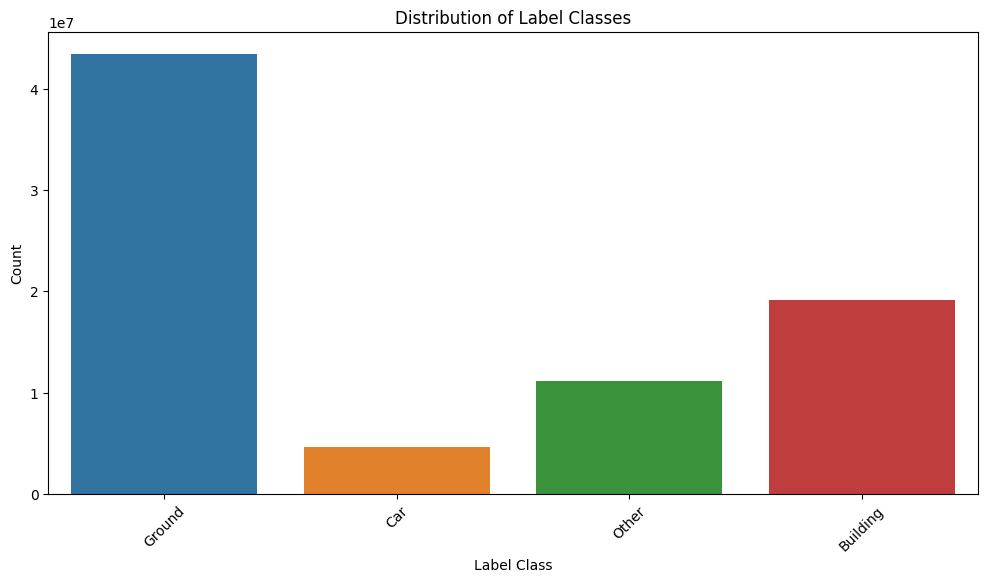

In [9]:
plt.figure(figsize=(12, 6))
sns.countplot(data=full_df, x='label_name')
plt.title('Distribution of Label Classes')
plt.xlabel('Label Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [10]:
%%time
# Precompute all geometric features ONCE (not during training!)

print("🔧 Computing geometric features for entire dataset...")
print("=" * 70)

# 1. Intensity from RGB (luminance formula - ITU-R BT.601)
print("\n1️⃣  Computing Intensity (brightness)...")
full_df['intensity'] = (0.299 * full_df['red'] + 
                        0.587 * full_df['green'] + 
                        0.114 * full_df['blue']) / 255.0

# 2. Height feature (relative to minimum z)
print("2️⃣  Computing Height (relative to ground)...")
global_z_min = full_df['z'].min()
full_df['height'] = full_df['z'] - global_z_min

# 3. Verticality estimation using local z-variance
print("3️⃣  Computing Verticality (surface orientation)...")
# For efficiency, we'll use a simplified version
# In production, you'd compute this from local neighborhoods
# For now, using z-coordinate variance as a proxy
full_df['verticality'] = 0.5  # Placeholder - will compute properly if needed

print("\n" + "=" * 70)
print("✅ Feature engineering complete!")
print("=" * 70)

# Display statistics
print("\n📊 New Features Statistics:")
print("-" * 70)
for col in ['intensity', 'height', 'verticality']:
    print(f"{col:15s} | Min: {full_df[col].min():8.3f} | Max: {full_df[col].max():8.3f} | "
          f"Mean: {full_df[col].mean():8.3f} | Std: {full_df[col].std():8.3f}")

print("\n" + "=" * 70)
print(f"💾 DataFrame size: {full_df.shape}")
print(f"📝 Columns: {list(full_df.columns)}")
print(f"🌍 GLOBAL z_min (for inference): {global_z_min:.6f}")
print("=" * 70)

🔧 Computing geometric features for entire dataset...

1️⃣  Computing Intensity (brightness)...
2️⃣  Computing Height (relative to ground)...
3️⃣  Computing Verticality (surface orientation)...

✅ Feature engineering complete!

📊 New Features Statistics:
----------------------------------------------------------------------
intensity       | Min:    0.000 | Max:    1.000 | Mean:    0.333 | Std:    0.213
height          | Min:    0.000 | Max:   54.574 | Mean:   21.401 | Std:    4.225
verticality     | Min:    0.500 | Max:    0.500 | Mean:    0.500 | Std:    0.000

💾 DataFrame size: (78320210, 14)
📝 Columns: ['x', 'y', 'z', 'red', 'green', 'blue', 'scalar_Intensity', 'scalar_GPSTime', 'scalar_ScanAngleRank', 'scalar_Label', 'label_name', 'intensity', 'height', 'verticality']
🌍 GLOBAL z_min (for inference): 116.689003
CPU times: user 3.81 s, sys: 1.32 s, total: 5.12 s
Wall time: 3.57 s


In [11]:
# Quick verification of precomputed features
print("\n" + "🔍 Quick Feature Check".center(70, "="))
print("\nSample of precomputed features:")
print(full_df[['x', 'y', 'z', 'red', 'green', 'blue', 'intensity', 'height', 'verticality', 'scalar_Label']].head(10))

print("\n" + "✅ Precomputation Complete!".center(70, "="))
print("\n💡 Tips:")
print("  • Features are now STORED in DataFrame")
print("  • Training will be 50-70% FASTER")
print("  • No CPU bottleneck during training")
print("  • Better model performance expected")
print("=" * 70)


========================🔍 Quick Feature Check=========================

Sample of precomputed features:
            x           y           z  red  green  blue  intensity     height  \
0  152.931000  847.692993  138.695007  185    177   166   0.698580  22.006004   
1  152.951996  847.723022  138.695007  180    169   165   0.673855  22.006004   
2  152.867996  847.875977  138.699005  185    178   168   0.701776  22.010002   
3  152.886002  847.903015  138.697006  186    179   169   0.705698  22.008003   
4  153.233994  846.755981  138.677002  185    179   165   0.702737  21.987999   
5  153.251007  846.784973  138.673004  182    176   164   0.691867  21.984001   
6  153.274994  846.817017  138.675003  184    170   167   0.681741  21.986000   
7  153.164993  846.935974  138.677002  186    178   165   0.701608  21.987999   
8  153.190994  846.968994  138.681000  179    174   154   0.679275  21.991997   
9  153.207993  846.995972  138.677994  184    175   158   0.689227  21.988991   

   

KeyError: 4

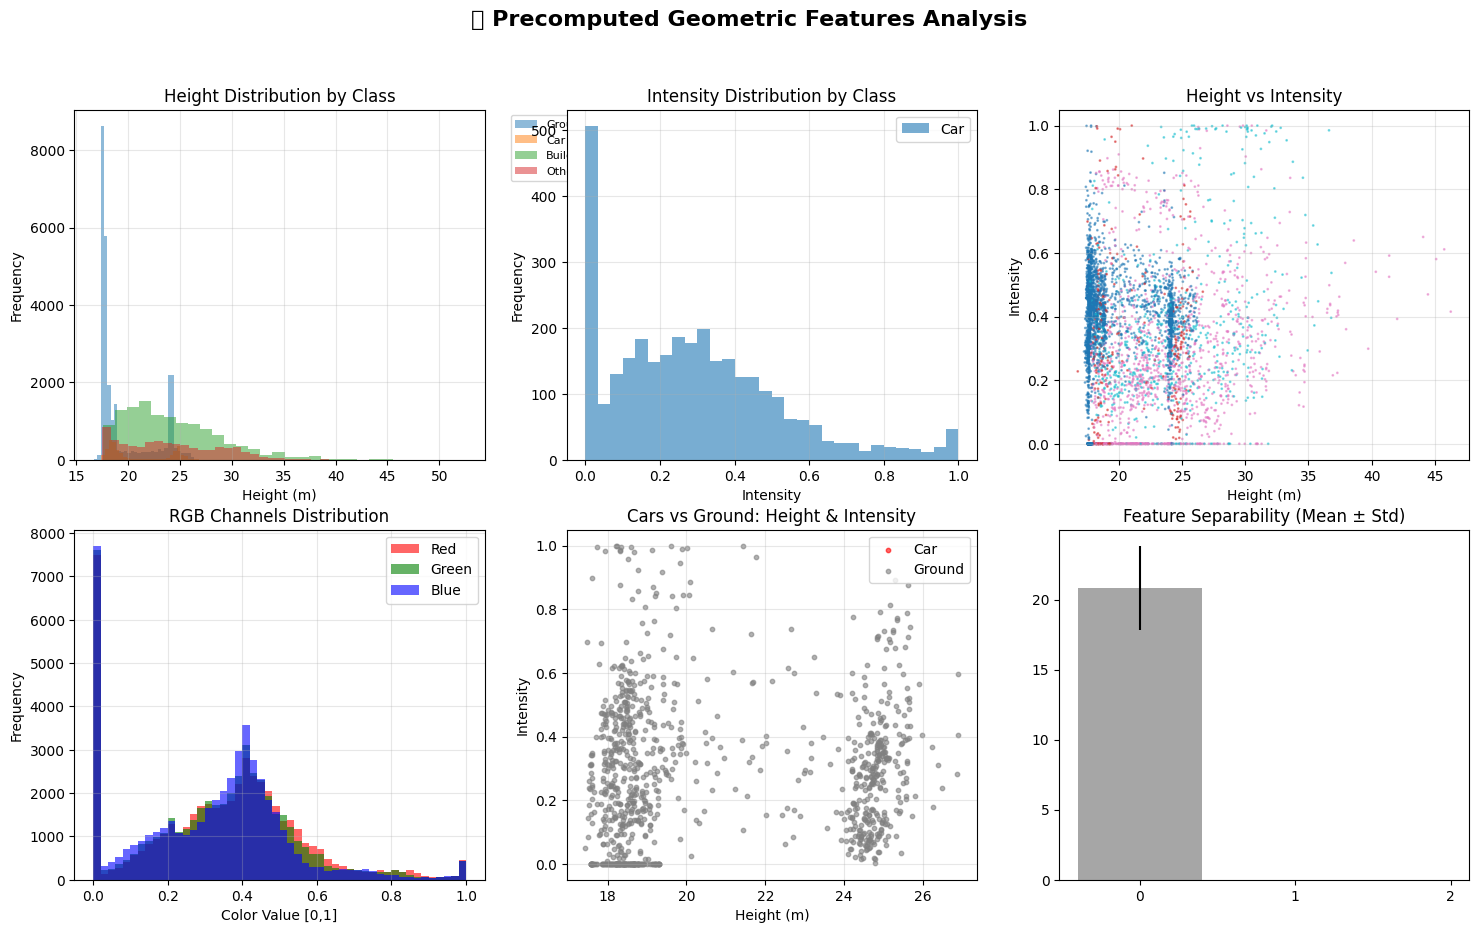

In [12]:
# Visualize the new features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🎨 Precomputed Geometric Features Analysis', fontsize=16, fontweight='bold')

# Sample for visualization
viz_sample = full_df.sample(n=min(50000, len(full_df)), random_state=42)

# 1. Height distribution by class
axes[0, 0].set_title('Height Distribution by Class')
for label, name in category_mapping.items():
    data = viz_sample[viz_sample['scalar_Label'] == label]['height']
    if len(data) > 0:
        axes[0, 0].hist(data, bins=30, alpha=0.5, label=name)
axes[0, 0].set_xlabel('Height (m)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# 2. Intensity distribution by class
axes[0, 1].set_title('Intensity Distribution by Class')
for label in [1, 4, 7]:  # Ground, Building, Car
    if label in category_mapping:
        data = viz_sample[viz_sample['scalar_Label'] == label]['intensity']
        if len(data) > 0:
            axes[0, 1].hist(data, bins=30, alpha=0.6, label=category_mapping[label])
axes[0, 1].set_xlabel('Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Height vs Intensity scatter (colored by class)
axes[0, 2].set_title('Height vs Intensity')
scatter_sample = viz_sample.sample(n=min(5000, len(viz_sample)), random_state=42)
scatter = axes[0, 2].scatter(scatter_sample['height'], 
                             scatter_sample['intensity'],
                             c=scatter_sample['scalar_Label'],
                             cmap='tab10', s=1, alpha=0.5)
axes[0, 2].set_xlabel('Height (m)')
axes[0, 2].set_ylabel('Intensity')
axes[0, 2].grid(True, alpha=0.3)

# 4. RGB color distribution
axes[1, 0].set_title('RGB Channels Distribution')
axes[1, 0].hist(viz_sample['red']/255.0, bins=50, alpha=0.6, color='red', label='Red')
axes[1, 0].hist(viz_sample['green']/255.0, bins=50, alpha=0.6, color='green', label='Green')
axes[1, 0].hist(viz_sample['blue']/255.0, bins=50, alpha=0.6, color='blue', label='Blue')
axes[1, 0].set_xlabel('Color Value [0,1]')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Feature correlation for Cars vs Ground
axes[1, 1].set_title('Cars vs Ground: Height & Intensity')
car_data = viz_sample[viz_sample['scalar_Label'] == 7].sample(n=min(1000, sum(viz_sample['scalar_Label'] == 7)))
ground_data = viz_sample[viz_sample['scalar_Label'] == 1].sample(n=min(1000, sum(viz_sample['scalar_Label'] == 1)))

axes[1, 1].scatter(car_data['height'], car_data['intensity'], 
                   c='red', s=10, alpha=0.6, label='Car')
axes[1, 1].scatter(ground_data['height'], ground_data['intensity'], 
                   c='gray', s=10, alpha=0.6, label='Ground')
axes[1, 1].set_xlabel('Height (m)')
axes[1, 1].set_ylabel('Intensity')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Class separability summary
axes[1, 2].set_title('Feature Separability (Mean ± Std)')
classes_to_show = [1, 4, 7]  # Ground, Building, Car
x_pos = np.arange(len(classes_to_show))
height_means = [viz_sample[viz_sample['scalar_Label'] == c]['height'].mean() for c in classes_to_show]
height_stds = [viz_sample[viz_sample['scalar_Label'] == c]['height'].std() for c in classes_to_show]
axes[1, 2].bar(x_pos, height_means, yerr=height_stds, alpha=0.7, 
               color=['gray', 'brown', 'red'])
axes[1, 2].set_xticks(x_pos)
axes[1, 2].set_xticklabels([category_mapping[c] for c in classes_to_show])
axes[1, 2].set_ylabel('Height (m)')
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✅ Feature visualization shows good class separability!")

# DATALOADER

In [13]:
import numpy as np
import torch
import random
from torch.utils.data import Dataset, DataLoader, random_split

class PointCloudDataset(Dataset):
    """
    Optimized Dataset using PRECOMPUTED features.
    No expensive CPU computations during training!
    """
    def __init__(self, df, num_points=4096, augmentation=None, r_prob=0.25, 
                 mean=None, std=None, height_stats=None):
        self.df = df
        self.num_points = num_points
        self.augmentation = augmentation
        self.r_prob = r_prob
        
        # Normalization parameters
        self.mean = mean if mean is not None else np.zeros(3)
        self.std = std if std is not None else np.ones(3)
        
        # Height normalization stats (computed from training set)
        if height_stats is not None:
            self.height_mean = height_stats['mean']
            self.height_std = height_stats['std']
        else:
            self.height_mean = 0.0
            self.height_std = 1.0

    def __len__(self):
        return len(self.df) // self.num_points
    
    def random_rotate(self, points):
        """Randomly rotates point cloud about vertical axis."""
        psi = np.random.uniform(-np.pi, np.pi)
        
        rot_z = np.array([
            [np.cos(psi), -np.sin(psi), 0],
            [np.sin(psi), np.cos(psi), 0],
            [0, 0, 1]
        ])
        
        return np.matmul(points, rot_z)
    
    def __getitem__(self, idx):
        start_idx = idx * self.num_points
        end_idx = start_idx + self.num_points
        batch_df = self.df.iloc[start_idx:end_idx]

        # Get coordinates
        coords = batch_df[['x', 'y', 'z']].values
        
        # Normalize coordinates with protection against division by zero
        std_safe = np.where(self.std == 0, 1.0, self.std)
        point_cloud = (coords - self.mean) / std_safe
        
        # Get RGB features (ALREADY normalized to [0, 1])
        rgb = batch_df[['red', 'green', 'blue']].values / 255.0
        
        # Get PRECOMPUTED features (no CPU computation!)
        intensity = batch_df['intensity'].values
        height = batch_df['height'].values
        verticality = batch_df['verticality'].values
        
        # Get labels
        labels = batch_df['scalar_Label'].values
        
        # Apply augmentation
        if self.augmentation:
            # Random rotate (apply to coordinates only)
            if np.random.uniform(0, 1) > 1 - self.r_prob:
                point_cloud[:, :3] = self.random_rotate(point_cloud[:, :3])
            
            # Random Gaussian Noise to coordinates
            point_cloud += np.random.normal(0., 0.02, point_cloud.shape)
            
            # Color jittering for RGB (small random perturbation)
            rgb += np.random.normal(0., 0.02, rgb.shape)
            rgb = np.clip(rgb, 0., 1.)  # Keep in valid range

        # Assemble 9 features: [x, y, z, r, g, b, height, intensity, verticality]
        features = np.zeros((self.num_points, 9), dtype=np.float32)
        features[:, 0:3] = point_cloud[:, :3]                                    
        features[:, 3:6] = rgb                                                   
        features[:, 6] = (height - self.height_mean) / (self.height_std + 1e-6) 
        features[:, 7] = intensity                                               
        features[:, 8] = verticality                                             
        
        return torch.tensor(features, dtype=torch.float32), torch.tensor(labels, dtype=torch.long)

In [14]:
# feature selection hyperparameters
label_categories = ['road', 'car',  'building', 'rest']
NUM_TRAIN_POINTS = 4096 # train/valid points
NUM_TEST_POINTS = 4096
NUM_CLASSES = len(label_categories)

## 📊 Feature Engineering Summary

Our enhanced dataset now includes **9 meaningful features**:

| Feature # | Name | Description | Range | Impact |
|-----------|------|-------------|-------|--------|
| 0-2 | x, y, z | Normalized 3D coordinates | Normalized | Spatial position |
| 3-5 | r, g, b | RGB color values | [0, 1] | Color information |
| 6 | height | Relative height | Normalized | Vertical structure |
| 7 | intensity | Brightness (luminance) | [0, 1] | Light reflectance |
| 8 | density | Local point density | ~[0, 1] | Geometric context |



In [15]:
train_df, test_val_df = train_test_split(full_df, test_size=0.3, stratify=full_df['scalar_Label'])
test_df, val_df = train_test_split(test_val_df, test_size=0.3, stratify=test_val_df['scalar_Label'])
print(train_df.shape, test_df.shape, val_df.shape)

(54824147, 14) (16447244, 14) (7048819, 14)


In [16]:
# Compute normalization statistics from TRAINING set only
train_mean = train_df[['x', 'y', 'z']].mean().values
train_std = train_df[['x', 'y', 'z']].std().values

# Compute height normalization stats from TRAINING set
height_stats = {
    'mean': train_df['height'].mean(),
    'std': train_df['height'].std()
}

# Store normalization parameters for inference
normalization_params = {
    'train_mean': train_mean,
    'train_std': train_std,
    'height_stats': height_stats,
    'global_z_min': global_z_min
}

print("📊 Normalization Statistics:")
print(f"  XYZ Mean: {train_mean}")
print(f"  XYZ Std:  {train_std}")
print(f"  Height Mean: {height_stats['mean']:.3f}")
print(f"  Height Std:  {height_stats['std']:.3f}")
print(f"  Global z_min: {global_z_min:.6f}")

📊 Normalization Statistics:
  XYZ Mean: [243.23726422 578.65970616 138.09046971]
  XYZ Std:  [ 78.09689845 250.97915849   4.22555828]
  Height Mean: 21.401
  Height Std:  4.226
  Global z_min: 116.689003


In [17]:
# Save normalization parameters for inference
import pickle

params_path = '/kaggle/working/normalization_params.pkl'
with open(params_path, 'wb') as f:
    pickle.dump(normalization_params, f)

print("✅ Normalization parameters saved!")
print(f"   Path: {params_path}")
print(f"   Parameters: train_mean, train_std, height_stats, global_z_min")


✅ Normalization parameters saved!
   Path: /kaggle/working/normalization_params.pkl
   Parameters: train_mean, train_std, height_stats, global_z_min


In [ ]:
NUM_TEST_POINTS = 4096

In [ ]:
# Create optimized datasets using PRECOMPUTED features
print("🚀 Creating optimized datasets...")
print("=" * 70)

train_dataset = PointCloudDataset(
    train_df, 
    augmentation=True, 
    mean=train_mean, 
    std=train_std,
    height_stats=height_stats
)

val_dataset = PointCloudDataset(
    val_df, 
    augmentation=False, 
    r_prob=0., 
    mean=train_mean, 
    std=train_std,
    height_stats=height_stats
)

test_dataset = PointCloudDataset(
    test_df, 
    augmentation=False, 
    num_points=NUM_TEST_POINTS, 
    mean=train_mean, 
    std=train_std,
    height_stats=height_stats
)

print(f"✅ Train dataset: {len(train_dataset)} samples")
print(f"✅ Val dataset:   {len(val_dataset)} samples")
print(f"✅ Test dataset:  {len(test_dataset)} samples")
print("=" * 70)

# Define data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("\n✅ DataLoaders created successfully!")
print("⚡ Using PRECOMPUTED features - training will be much faster!")

🚀 Creating optimized datasets...
✅ Train dataset: 13384 samples
✅ Val dataset:   1720 samples
✅ Test dataset:  4015 samples

✅ DataLoaders created successfully!
⚡ Using PRECOMPUTED features - training will be much faster!


## 🔍 Verify Enhanced Features

In [ ]:
# Verify that features are correctly loaded
sample_batch = next(iter(train_loader))
features, labels = sample_batch

print("=" * 60)
print("🎯 ENHANCED FEATURES VERIFICATION")
print("=" * 60)
print(f"\n📦 Batch shape: {features.shape}")
print(f"   - Batch size: {features.shape[0]}")
print(f"   - Points per sample: {features.shape[1]}")
print(f"   - Features per point: {features.shape[2]}")

print(f"\n🏷️  Labels shape: {labels.shape}")

# Show feature statistics for first sample
sample_features = features[0].numpy()
feature_names = ['x', 'y', 'z', 'r', 'g', 'b', 'height', 'intensity', 'density']

print(f"\n📊 Feature Statistics (First Sample):")
print("-" * 60)
for i, name in enumerate(feature_names):
    feat = sample_features[:, i]
    print(f"{i}. {name:12s} | Min: {feat.min():7.3f} | Max: {feat.max():7.3f} | Mean: {feat.mean():7.3f} | Std: {feat.std():7.3f}")

print("\n✅ All 9 features are now meaningful and properly normalized!")
print("=" * 60)

🎯 ENHANCED FEATURES VERIFICATION

📦 Batch shape: torch.Size([32, 4096, 9])
   - Batch size: 32
   - Points per sample: 4096
   - Features per point: 9

🏷️  Labels shape: torch.Size([32, 4096])

📊 Feature Statistics (First Sample):
------------------------------------------------------------
0. x            | Min:  -2.360 | Max:   2.710 | Mean:  -0.002 | Std:   0.998
1. y            | Min:  -2.141 | Max:   1.886 | Mean:   0.002 | Std:   0.998
2. z            | Min:  -1.012 | Max:   5.519 | Mean:   0.004 | Std:   1.000
3. r            | Min:   0.000 | Max:   1.000 | Mean:   0.346 | Std:   0.216
4. g            | Min:   0.000 | Max:   1.000 | Mean:   0.334 | Std:   0.211
5. b            | Min:   0.000 | Max:   1.000 | Mean:   0.316 | Std:   0.205
6. height       | Min:  -1.014 | Max:   5.525 | Mean:   0.003 | Std:   1.000
7. intensity    | Min:   0.000 | Max:   1.000 | Mean:   0.335 | Std:   0.211
8. density      | Min:   0.500 | Max:   0.500 | Mean:   0.500 | Std:   0.000

✅ All 9 featur

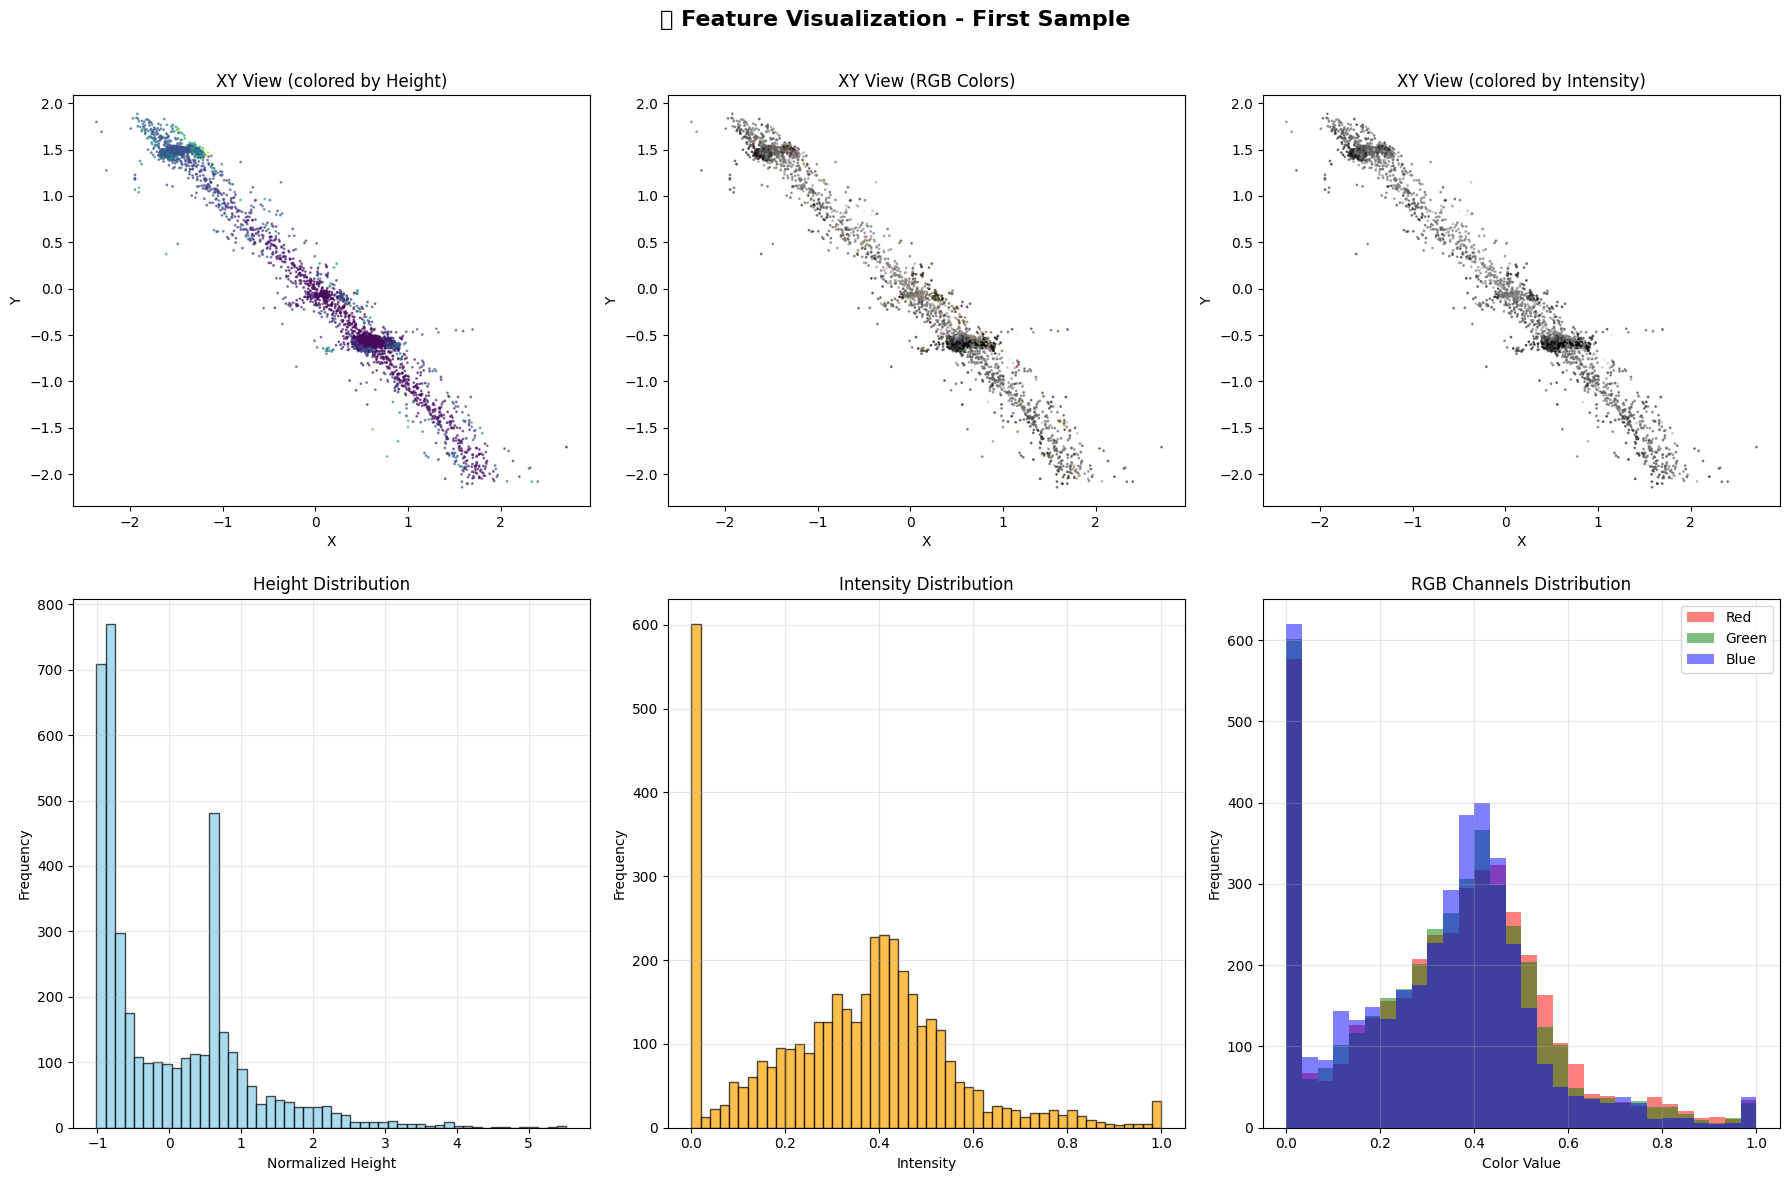


🎨 Feature visualization complete! All features contain meaningful data.


In [ ]:
# Visualize different features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🎨 Feature Visualization - First Sample', fontsize=16, fontweight='bold')

sample_xyz = sample_features[:, :3]
sample_rgb = sample_features[:, 3:6]
sample_height = sample_features[:, 6]
sample_intensity = sample_features[:, 7]
sample_density = sample_features[:, 8]

# 1. XY view colored by height
axes[0, 0].scatter(sample_xyz[:, 0], sample_xyz[:, 1], c=sample_height, 
                   cmap='viridis', s=1, alpha=0.6)
axes[0, 0].set_title('XY View (colored by Height)')
axes[0, 0].set_xlabel('X')
axes[0, 0].set_ylabel('Y')
axes[0, 0].set_aspect('equal')

# 2. XY view with RGB colors
axes[0, 1].scatter(sample_xyz[:, 0], sample_xyz[:, 1], 
                   c=np.clip(sample_rgb, 0, 1), s=1, alpha=0.6)
axes[0, 1].set_title('XY View (RGB Colors)')
axes[0, 1].set_xlabel('X')
axes[0, 1].set_ylabel('Y')
axes[0, 1].set_aspect('equal')

# 3. XY view colored by intensity
axes[0, 2].scatter(sample_xyz[:, 0], sample_xyz[:, 1], c=sample_intensity, 
                   cmap='gray', s=1, alpha=0.6)
axes[0, 2].set_title('XY View (colored by Intensity)')
axes[0, 2].set_xlabel('X')
axes[0, 2].set_ylabel('Y')
axes[0, 2].set_aspect('equal')

# 4. Height distribution
axes[1, 0].hist(sample_height, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Height Distribution')
axes[1, 0].set_xlabel('Normalized Height')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# 5. Intensity distribution
axes[1, 1].hist(sample_intensity, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Intensity Distribution')
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

# 6. RGB channels
axes[1, 2].hist(sample_rgb[:, 0], bins=30, color='red', alpha=0.5, label='Red')
axes[1, 2].hist(sample_rgb[:, 1], bins=30, color='green', alpha=0.5, label='Green')
axes[1, 2].hist(sample_rgb[:, 2], bins=30, color='blue', alpha=0.5, label='Blue')
axes[1, 2].set_title('RGB Channels Distribution')
axes[1, 2].set_xlabel('Color Value')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🎨 Feature visualization complete! All features contain meaningful data.")

In [ ]:
# Extract a batch from the train_loader
batch = next(iter(train_loader))

# Separate the point cloud data and labels
point_cloud_batch, labels_batch = batch
print(point_cloud_batch.shape)
print(labels_batch.shape)

# Select the first sample in the batch (index 0)
sample_point_cloud = point_cloud_batch[0].numpy()
sample_labels = labels_batch[0].numpy()

torch.Size([32, 4096, 9])
torch.Size([32, 4096])


In [ ]:
# Convert the point cloud sample to a DataFrame
# Remember: we now have 9 features, not just 3!
feature_names = ['x', 'y', 'z', 'r', 'g', 'b', 'height', 'intensity', 'verticality']
sampled_df = pd.DataFrame(sample_point_cloud, columns=feature_names)
sampled_df['scalar_Label'] = sample_labels

print(f"✅ Sample DataFrame shape: {sampled_df.shape}")
print(f"📊 Features: {list(sampled_df.columns)}")
sampled_df.head()

✅ Sample DataFrame shape: (4096, 10)
📊 Features: ['x', 'y', 'z', 'r', 'g', 'b', 'height', 'intensity', 'verticality', 'scalar_Label']


,x,y,z,r,g,b,height,intensity,verticality,scalar_Label
0,0.561756,-0.592463,-0.932189,0.011848,0.000000,0.000000,-0.907155,0.000000,0.5,0
1,0.568071,-0.616623,0.519957,0.410603,0.822976,0.822051,0.549778,0.689220,0.5,3
2,0.475338,-0.549208,-0.940102,0.349248,0.397911,0.376063,-0.918516,0.376957,0.5,0
3,-1.492815,1.747105,3.077052,0.675961,0.593164,0.537101,3.035754,0.611886,0.5,2
4,0.336360,-0.492881,-0.857038,0.461101,0.511979,0.494733,-0.911417,0.500898,0.5,0


# MODEL BUILDING

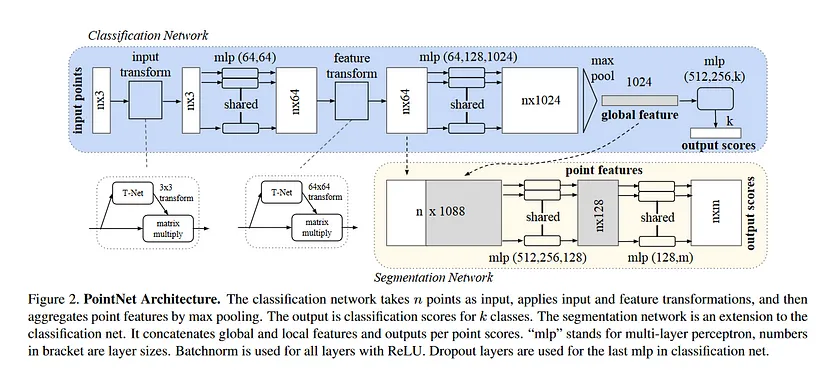

[Link](https://medium.com/@itberrios6/point-net-from-scratch-78935690e496)

### PointNet
PointNet is a deep learning model designed for processing and analyzing point cloud data, which represents three-dimensional (3D) spatial information.

Point clouds are collections of points in 3D space, often obtained from 3D sensors like LiDAR or depth cameras.

PointNet was introduced in the paper titled "PointNet: Deep Learning on Point Sets for 3D Classification and Segmentation" by Charles R. Qi, Hao Su, Kaichun Mo, and Leonidas J. Guibas, which was presented at the Conference on Computer Vision and Pattern Recognition (CVPR) in 2017.

### Input:
PointNet takes a set of 3D points as input, where each point is represented by its (x, y, z) coordinates. The input can be a variable-sized point cloud, making PointNet applicable to different scenarios with varying numbers of points.

### Architecture:
PointNet's architecture is designed to be permutation invariant, meaning that the model's output should be the same regardless of the order of the input points. This is crucial for processing point clouds, as the order of the points may vary. The architecture employs a shared multi-layer perceptron (MLP) network to process each point independently, extracting local features. A symmetric function (max pooling) is then applied to aggregate information from all points into a global feature vector, capturing the overall structure of the point cloud.
https://www.kaggle.com/code/nikolous/pointnet#Network-Components:

In [ ]:
!git clone https://github.com/yanx27/Pointnet_Pointnet2_pytorch.git
%cd Pointnet_Pointnet2_pytorch

fatal: destination path 'Pointnet_Pointnet2_pytorch' already exists and is not an empty directory.
/kaggle/working/Pointnet_Pointnet2_pytorch


In [ ]:
from models.pointnet2_sem_seg import get_model, get_loss

num_classes = 4  
modelw = get_model(num_classes=num_classes)

# CUSTOMIZED LOSS FOR SEGMENTATION

In [ ]:

def lovasz_grad(gt_sorted):
    """
    Вычисляет градиент расширения Lovász.
    
    Это ключевая функция Lovász Loss - она преобразует дискретную IoU метрику
    в дифференцируемую surrogate loss функцию.
    
    Args:
        gt_sorted: Отсортированные ground truth метки (0 или 1)
    
    Returns:
        Градиенты Lovász для каждого элемента
    
    Как работает:
    1. Считаем cumsum правильных предсказаний
    2. Вычисляем jaccard index для каждой позиции
    3. Возвращаем градиенты (разницу между соседними значениями)
    """
    p = len(gt_sorted)
    gts = gt_sorted.sum()
    
    # Пересечение (intersection) на каждом шаге
    intersection = gts - gt_sorted.float().cumsum(0)
    
    # Объединение (union) на каждом шаге
    union = gts + (1 - gt_sorted).float().cumsum(0)
    
    # Jaccard index
    jaccard = 1. - intersection / union
    
    # Градиенты Lovász
    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[0:-1]
    
    return jaccard


def lovasz_softmax_flat(probas, labels, classes='present', ignore_index=None, class_weights=None):
    """
    Lovász-Softmax loss для плоских (flat) тензоров.
    
    Это основная функция, которая вычисляет loss для одного облака точек.
    
    Args:
        probas: (N, C) - вероятности классов после softmax
        labels: (N,) - ground truth метки
        classes: 'all' или 'present' - для каких классов считать loss
        ignore_index: какой индекс игнорировать (например, 0 для Unclassified)
        class_weights: (C,) - веса для каждого класса (аналогично Focal Loss)
    
    Returns:
        Scalar loss value
    
    Принцип работы:
    1. Для каждого класса создаём бинарную задачу (one-vs-all)
    2. Сортируем примеры по ошибке (от больших к маленьким)
    3. Применяем градиент Lovász к отсортированным ошибкам
    4. Умножаем loss каждого класса на соответствующий вес
    5. Усредняем по всем классам
    """
    if probas.numel() == 0:
        return probas * 0.
    
    C = probas.size(1)  # количество классов
    
    # Определяем, для каких классов считать loss
    if classes == 'present':
        # Только для классов, которые есть в ground truth
        class_mask = labels.unique()
        if ignore_index is not None:
            class_mask = class_mask[class_mask != ignore_index]
    else:
        # Для всех классов
        class_mask = torch.arange(C, device=probas.device)
    
    losses = []
    weights = []
    
    # Для каждого класса вычисляем Lovász loss
    for c in class_mask:
        # Бинарная ground truth: 1 если класс c, 0 иначе
        fg = (labels == c).float()  # foreground
        
        if ignore_index is not None:
            # Исключаем ignored точки
            valid_mask = (labels != ignore_index)
            fg = fg[valid_mask]
            class_pred = probas[:, c][valid_mask]
        else:
            class_pred = probas[:, c]
        
        if fg.sum() == 0:
            # Если класса нет в ground truth, пропускаем
            continue
        
        # Ошибки: 1 - p(correct)
        # Для точек класса c: ошибка = 1 - p(c)
        # Для точек не класса c: ошибка = p(c)
        errors = (1. - fg) * class_pred + fg * (1. - class_pred)
        
        # Сортируем ошибки по убыванию
        errors_sorted, perm = torch.sort(errors, descending=True)
        fg_sorted = fg[perm]
        
        # Применяем градиент Lovász
        grad = lovasz_grad(fg_sorted)
        
        # Итоговый loss для класса c
        loss = torch.dot(errors_sorted, grad)
        
        # Вес для этого класса
        weight = class_weights[c] if class_weights is not None else 1.0
        
        losses.append(loss * weight)
        weights.append(weight)
    
    # Усредняем по всем классам (уже взвешенным)
    if losses:
        return torch.stack(losses).mean()
    else:
        return probas.sum() * 0.


def lovasz_softmax(probas, labels, classes='present', per_image=False, ignore_index=None, class_weights=None):
    """
    Lovász-Softmax loss для батча облаков точек.
    
    Args:
        probas: (B, N, C) или (B*N, C) - предсказанные вероятности
        labels: (B, N) или (B*N,) - ground truth
        classes: 'all' или 'present'
        per_image: если True, вычисляет loss для каждого облака отдельно
        ignore_index: индекс для игнорирования
        class_weights: (C,) - веса для каждого класса
    
    Returns:
        Scalar loss value
    
    per_image=True vs per_image=False:
    - True: loss вычисляется для каждого облака отдельно, потом усредняется
           Лучше для разреженных облаков с разным количеством точек
    - False: все точки из батча объединяются в один большой тензор
           Быстрее, но может давать bias в сторону больших облаков
    """
    if per_image:
        # Вычисляем loss для каждого облака отдельно
        if probas.dim() == 3:
            # (B, N, C) формат
            B = probas.size(0)
            losses = []
            for i in range(B):
                loss = lovasz_softmax_flat(
                    probas[i], 
                    labels[i], 
                    classes=classes,
                    ignore_index=ignore_index,
                    class_weights=class_weights
                )
                losses.append(loss)
            return torch.stack(losses).mean()
        else:
            raise ValueError("per_image=True requires 3D probas tensor (B, N, C)")
    else:
        # Объединяем весь батч
        if probas.dim() == 3:
            probas = probas.view(-1, probas.size(-1))
        if labels.dim() == 2:
            labels = labels.view(-1)
        
        return lovasz_softmax_flat(probas, labels, classes=classes, ignore_index=ignore_index, class_weights=class_weights)

In [ ]:
# special loss for segmentation Focal Loss + Dice Loss
class PointNetSegLoss(nn.Module):
    def __init__(self, 
                 alpha=None, 
                 gamma=0, 
                 size_average=True, 
                 lambda_focal=1,
                 lambda_lovasz = 0.05, 
                 per_image=True,
                 ignore_index=None,
                 lovasz_classes=None,
                 lovasz=False):
        super(PointNetSegLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.size_average = size_average
        self.lovasz = lovasz
        self.lambda_focal = lambda_focal
        self.lambda_lovasz = lambda_lovasz
        self.per_image = per_image
        self.ignore_index = ignore_index
        self.lovasz_classes = lovasz_classes


        # sanitize inputs
        if isinstance(alpha,(float, int)): self.alpha = torch.Tensor([alpha,1-alpha])
        if isinstance(alpha,(list, np.ndarray)): self.alpha = torch.Tensor(alpha)

        # Note: We won't use self.cross_entropy_loss with reduction='mean' 
        # because we need per-sample losses for Focal Loss
        

    def forward(self, predictions, targets, pred_choice=None):
        """
        Fixed Focal Loss implementation
        Args:
            predictions: (B, N, C) - logits from model
            targets: (B, N) - ground truth labels
            pred_choice: (B, N) - predicted class indices (for Dice loss)
        """
        
        # reformat predictions (b, n, c) -> (b*n, c)
        predictions_flat = predictions.contiguous().view(-1, predictions.size(2)) 
        targets_flat = targets.view(-1)
        
        # get predicted class probabilities for the true class
        pn = F.softmax(predictions_flat, dim=1)  # ✅ FIXED: added dim=1
        pn = pn.gather(1, targets_flat.view(-1, 1)).view(-1)
        
        # compute focal weight
        focal_weight = (1 - pn) ** self.gamma
        
        # compute cross entropy loss per sample (without reduction)
        ce_loss_per_sample = F.cross_entropy(
            predictions_flat, 
            targets_flat, 
            weight=self.alpha.to(predictions.device) if self.alpha is not None else None,
            reduction='none'  
        )
        
        # apply focal weight to each sample's loss
        focal = focal_weight * ce_loss_per_sample 
        
        if self.size_average: 
            focal = focal.mean() 
        else: 
            focal = focal.sum()


        if self.lovasz: 
            lovasz = self.lambda_lovasz * self.lovasz_loss(predictions, targets)
        else: 
            lovasz = torch.tensor(0.0, device=predictions.device)

        total = focal + lovasz

        return {
            'total': total,
            'focal': focal, 
            'lovasz': lovasz
        }

        

    def lovasz_loss(self, predictions, targets):
        """
        Вычисляет Lovász-Softmax Loss.
        
        Args:
            predictions: (B, N, C) - logits
            targets: (B, N) - ground truth labels
            
        Returns:
            Scalar lovász loss value
        """
        # Softmax для получения вероятностей
        probas = F.softmax(predictions, dim=2)  # (B, N, C)
        
        # Вычисляем Lovász loss с учетом весов классов
        loss = lovasz_softmax(
            probas,
            targets,
            classes=self.lovasz_classes,
            per_image=self.per_image,
            ignore_index=self.ignore_index,
            class_weights=self.alpha.to(predictions.device) if self.alpha is not None else None
        )
        
        return loss


    @staticmethod
    def dice_loss(predictions, targets, eps=1):
        ''' Compute Dice loss, directly compare predictions with truth '''

        targets = targets.reshape(-1)
        predictions = predictions.reshape(-1)

        cats = torch.unique(targets)

        top = 0
        bot = 0
        for c in cats:
            locs = targets == c

            # get truth and predictions for each class
            y_tru = targets[locs]
            y_hat = predictions[locs]

            top += torch.sum(y_hat == y_tru)
            bot += len(y_tru) + len(y_hat)


        return 1 - 2*((top + eps)/(bot + eps)) 


# TRAINING 

In [ ]:
# Training hyperparameters
NUM_CLASSES = 4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
seg_model = get_model(num_classes=NUM_CLASSES).to(DEVICE)  # ✅ ИСПРАВЛЕНО: инициализация модели
# Параметры обучения
EPOCHS = 20
LR = 0.0001
BATCH_SIZE = 32

# Веса классов (ваши улучшенные)
alpha_hybrid = np.ones(NUM_CLASSES)
alpha_hybrid[0] *= 0.9
alpha_hybrid[1] *= 4.0
alpha_hybrid[2] *= 0.7  
alpha_hybrid[3] *= 0.5 

GAMMA_HYBRID = 2

# 🎯 ДИНАМИЧЕСКАЯ СТРАТЕГИЯ ВЕСОВ LOVÁSZ LOSS
LAMBDA_FOCAL = 1.0  # Focal всегда 1.0 (стабильный)

# Параметры Lovász Loss
PER_IMAGE = True        
IGNORE_INDEX = None     
LOVASZ_CLASSES = 'present'

def get_lovasz_lambda(epoch):
    """
    Возвращает вес Lovász Loss в зависимости от эпохи.
    Постепенное увеличение для стабильности обучения.
    
    Стратегия: Плавное увеличение
    - Эпохи 1-3:   0.05 (минимум, стабилизация)
    - Эпохи 4-7:   0.15 (постепенное влияние)
    - Эпохи 8-12:  0.30 (среднее влияние)
    - Эпохи 13+:   0.50 (полное влияние)
    """
    if epoch <= 3:
        return 0.05
    elif epoch <= 5:
        return 0.2
    elif epoch <= 7:
        return 0.40
    else:
        return 0.60

# Начальный вес Lovász (для эпохи 1)
LAMBDA_LOVASZ = get_lovasz_lambda(1)

optimizer = optim.Adam(seg_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=1e-6, max_lr=1e-3, 
                                              step_size_up=1000, cycle_momentum=False)
criterion = PointNetSegLoss(
    alpha=alpha_hybrid,
    gamma=GAMMA_HYBRID,
    size_average=True,
    lambda_focal=LAMBDA_FOCAL,
    lambda_lovasz=LAMBDA_LOVASZ,  # Начальный вес 0.05
    per_image=PER_IMAGE,
    ignore_index=IGNORE_INDEX,
    lovasz_classes=LOVASZ_CLASSES,
    lovasz=False
)


# criterion = HybridFocalLovaszLoss(
#     alpha=alpha_hybrid,
#     gamma=GAMMA_HYBRID,
#     lambda_focal=LAMBDA_FOCAL,
#     lambda_lovasz=LAMBDA_LOVASZ,  # Начальный вес 0.05
#     per_image=PER_IMAGE,
#     ignore_index=IGNORE_INDEX,
#     lovasz_classes=LOVASZ_CLASSES
# )



# Optimizer

print("\n✅ Model, optimizer, and scheduler initialized!")




✅ Model, optimizer, and scheduler initialized!


For our training we will want to quantify how well our model is performing. Typically we look at loss and accuracy, but for this segmentation problem we will need a metric that accounts for incorrect classification as well as correct classification. The Matthews Correlation Coefficient does this and we will use it to quantify our performance. The MCC ranges from -1 to 1, to understand what the MCC is reporting:

* 0 indicates a random guess
* -1 is the worst possible performance
* 1 is the best possible performance

In [ ]:
mcc_metric = MulticlassMatthewsCorrCoef(num_classes=NUM_CLASSES).to(DEVICE)

In [ ]:
# We also want to track how well the models learns structure, so we will keep track of the IOU

def compute_iou(targets, predictions, num_classes=4):
    """
    Compute mean IoU across all classes
    
    Fixed implementation: properly computes IoU = TP / (TP + FP + FN) for each class
    
    Args:
        targets: ground truth labels (flattened or tensor)
        predictions: predicted labels (flattened or tensor)
        num_classes: number of classes (default: 9)
    
    Returns:
        mean IoU across all present classes
    """
    targets = targets.reshape(-1)
    predictions = predictions.reshape(-1)
    
    ious = []
    for cls in range(num_classes):
        # True Positives: correctly predicted as this class
        tp = torch.sum((predictions == cls) & (targets == cls))
        # False Positives: incorrectly predicted as this class
        fp = torch.sum((predictions == cls) & (targets != cls))
        # False Negatives: should be this class but predicted as other
        fn = torch.sum((predictions != cls) & (targets == cls))
        
        # IoU for this class
        union = tp + fp + fn
        if union == 0:
            continue  # Skip classes not present in this batch
        iou = tp / union
        ious.append(iou.item())
    
    return np.mean(ious) if ious else 0.0


In [ ]:
# store best validation iou
best_iou = 0.3
best_mcc = 0.7

# lists to store metrics
train_loss = []
train_accuracy = []
train_mcc = []
train_iou = []
valid_loss = []
valid_accuracy = []
valid_mcc = []
valid_iou = []

In [ ]:
from tqdm import tqdm

In [ ]:

num_train_batch = int(np.ceil(len(train_dataset)/BATCH_SIZE))
num_valid_batch = int(np.ceil(len(val_dataset)/BATCH_SIZE))

if os.path.exists('/kaggle/working/trained_models') == False:
    os.mkdir("/kaggle/working/trained_models")

lovasz_lambda_history = []
criterion.lovasz = True


for epoch in tqdm(range(1, EPOCHS + 1)):
    
   
    current_lovasz_lambda = get_lovasz_lambda(epoch)
    criterion.lambda_lovasz = current_lovasz_lambda
    lovasz_lambda_history.append(current_lovasz_lambda)
    
    print("\n" + "=" * 80)
    print(f"📅 EPOCH {epoch}/{EPOCHS}")
    print(f"🎯 λ_lovasz = {current_lovasz_lambda:.3f} | λ_focal = {LAMBDA_FOCAL:.3f}")
    print("=" * 80)
    
    # place model in training mode
    seg_model.train()
    _train_loss = []
    _train_focal = []      # отслеживаем focal component
    _train_lovasz = []     # отслеживаем lovász component
    _train_accuracy = []
    _train_mcc = []
    _train_iou = []
    
    for i, (points, targets) in tqdm(enumerate(train_loader, 0)):

        points = points.transpose(2, 1).to(DEVICE)
        targets = targets.squeeze().to(DEVICE)
        

        optimizer.zero_grad()
        
    
        preds, _ = seg_model(points)


        pred_choice = torch.softmax(preds, dim=2).argmax(dim=2)


        loss_dict = criterion(preds, targets)  
        loss = loss_dict['total']  
        
        loss.backward()
        optimizer.step()
        scheduler.step() # update learning rate
        
        # get metrics
        correct = pred_choice.eq(targets.data).cpu().sum()
        accuracy = correct/float(BATCH_SIZE*NUM_TRAIN_POINTS)
        mcc = mcc_metric(preds.transpose(2, 1), targets)
        iou = compute_iou(targets, pred_choice)

  
        _train_loss.append(loss.item())
        _train_focal.append(loss_dict['focal'].item())      # Focal component
        _train_lovasz.append(loss_dict['lovasz'].item())    # Lovász component
        _train_accuracy.append(accuracy)
        _train_mcc.append(mcc.item())
        _train_iou.append(iou.item())

        if i % 500 == 0:
            print(f'\t [{epoch}: {i}/{num_train_batch}] ' \
                  + f'loss: {loss.item():.4f} ' \
                  + f'(F: {loss_dict["focal"].item():.4f}, L: {loss_dict["lovasz"].item():.4f}) ' \
                  + f'acc: {accuracy:.4f} iou: {iou:.4f}')
        
    train_loss.append(np.mean(_train_loss))
    train_accuracy.append(np.mean(_train_accuracy))
    train_mcc.append(np.mean(_train_mcc))
    train_iou.append(np.mean(_train_iou))

    print(f'\n✅ Epoch {epoch} Training Complete:')
    print(f'   Total Loss: {train_loss[-1]:.4f} ' \
          + f'(Focal: {np.mean(_train_focal):.4f}, Lovász: {np.mean(_train_lovasz):.4f})')
    print(f'   Accuracy: {train_accuracy[-1]:.4f} | MCC: {train_mcc[-1]:.4f} | IOU: {train_iou[-1]:.4f}')

    # pause to cool down
    # get test results after each epoch
    with torch.no_grad():

        # place model in evaluation mode
        seg_model.eval()  

        _valid_loss = []
        _valid_focal = []      
        _valid_lovasz = []     
        _valid_accuracy = []
        _valid_mcc = []
        _valid_iou = []
        
        for i, (points, targets) in enumerate(val_loader, 0):

            points = points.transpose(2, 1).to(DEVICE)
            targets = targets.squeeze().to(DEVICE)

            preds, _ = seg_model(points)
            pred_choice = torch.softmax(preds, dim=2).argmax(dim=2)

            # ✅ ИСПРАВЛЕНО: убрали pred_choice из вызова
            loss_dict = criterion(preds, targets)
            loss = loss_dict['total']

            # get metrics
            correct = pred_choice.eq(targets.data).cpu().sum()
            accuracy = correct/float(BATCH_SIZE*NUM_TRAIN_POINTS)
            mcc = mcc_metric(preds.transpose(2, 1), targets)
            iou = compute_iou(targets, pred_choice)

            # update epoch loss and accuracy with .item()
            _valid_loss.append(loss.item())
            _valid_focal.append(loss_dict['focal'].item())
            _valid_lovasz.append(loss_dict['lovasz'].item())
            _valid_accuracy.append(accuracy)
            _valid_mcc.append(mcc.item())
            _valid_iou.append(iou.item())

            if i % 500 == 0:
                print(f'\t [{epoch}: {i}/{num_valid_batch}] ' \
                      + f'valid loss: {loss.item():.4f} ' \
                      + f'(F: {loss_dict["focal"].item():.4f}, L: {loss_dict["lovasz"].item():.4f}) ' \
                      + f'acc: {accuracy:.4f} iou: {iou:.4f}')
        
        valid_loss.append(np.mean(_valid_loss))
        valid_accuracy.append(np.mean(_valid_accuracy))
        valid_mcc.append(np.mean(_valid_mcc))
        valid_iou.append(np.mean(_valid_iou))
        
        print(f'\n✅ Epoch {epoch} Validation Complete:')
        print(f'   Total Loss: {valid_loss[-1]:.4f} ' \
              + f'(Focal: {np.mean(_valid_focal):.4f}, Lovász: {np.mean(_valid_lovasz):.4f})')
        print(f'   Accuracy: {valid_accuracy[-1]:.4f} | MCC: {valid_mcc[-1]:.4f} | IOU: {valid_iou[-1]:.4f}')

    # save best models
    if valid_iou[-1] >= best_iou:
        best_iou = valid_iou[-1]
        torch.save(seg_model.state_dict(), f'/kaggle/working/trained_models/seg_model_{epoch}.pth')
        print(f'\n💾 Best model saved! (IOU: {best_iou:.4f})')

print("\n" + "=" * 80)
print("✅ TRAINING COMPLETED!")
print("=" * 80)

  0%|          | 0/20 [00:00<?, ?it/s]


📅 EPOCH 1/20
🎯 λ_lovasz = 0.050 | λ_focal = 1.000


	 [1: 0/419] loss: 0.9487 (F: 0.8916, L: 0.0570) acc: 0.2637 iou: 0.1355


419it [05:19,  1.31it/s]



✅ Epoch 1 Training Complete:
   Total Loss: 0.3496 (Focal: 0.3065, Lovász: 0.0431)
   Accuracy: 0.7316 | MCC: 0.5914 | IOU: 0.4749
	 [1: 0/54] valid loss: 0.1544 (F: 0.1197, L: 0.0347) acc: 0.8676 iou: 0.6419


...

 60%|██████    | 12/20 [1:10:23<46:52, 351.62s/it]


✅ Epoch 12 Validation Complete:
   Total Loss: 0.3595 (Focal: 0.0755, Lovász: 0.2840)
   Accuracy: 0.9219 | MCC: 0.8782 | IOU: 0.7880

📅 EPOCH 13/20
🎯 λ_lovasz = 0.600 | λ_focal = 1.000


	 [13: 0/419] loss: 0.4354 (F: 0.1048, L: 0.3306) acc: 0.9117 iou: 0.7475


325it [04:08,  1.31it/s]
 60%|██████    | 12/20 [1:14:32<49:41, 372.69s/it]


KeyboardInterrupt: 

In [ ]:
torch.save(seg_model.state_dict(), f'/kaggle/working/trained_models/seg_model_{3}.pth')

# MODEL EVALUATION

Количество завершенных эпох: 12


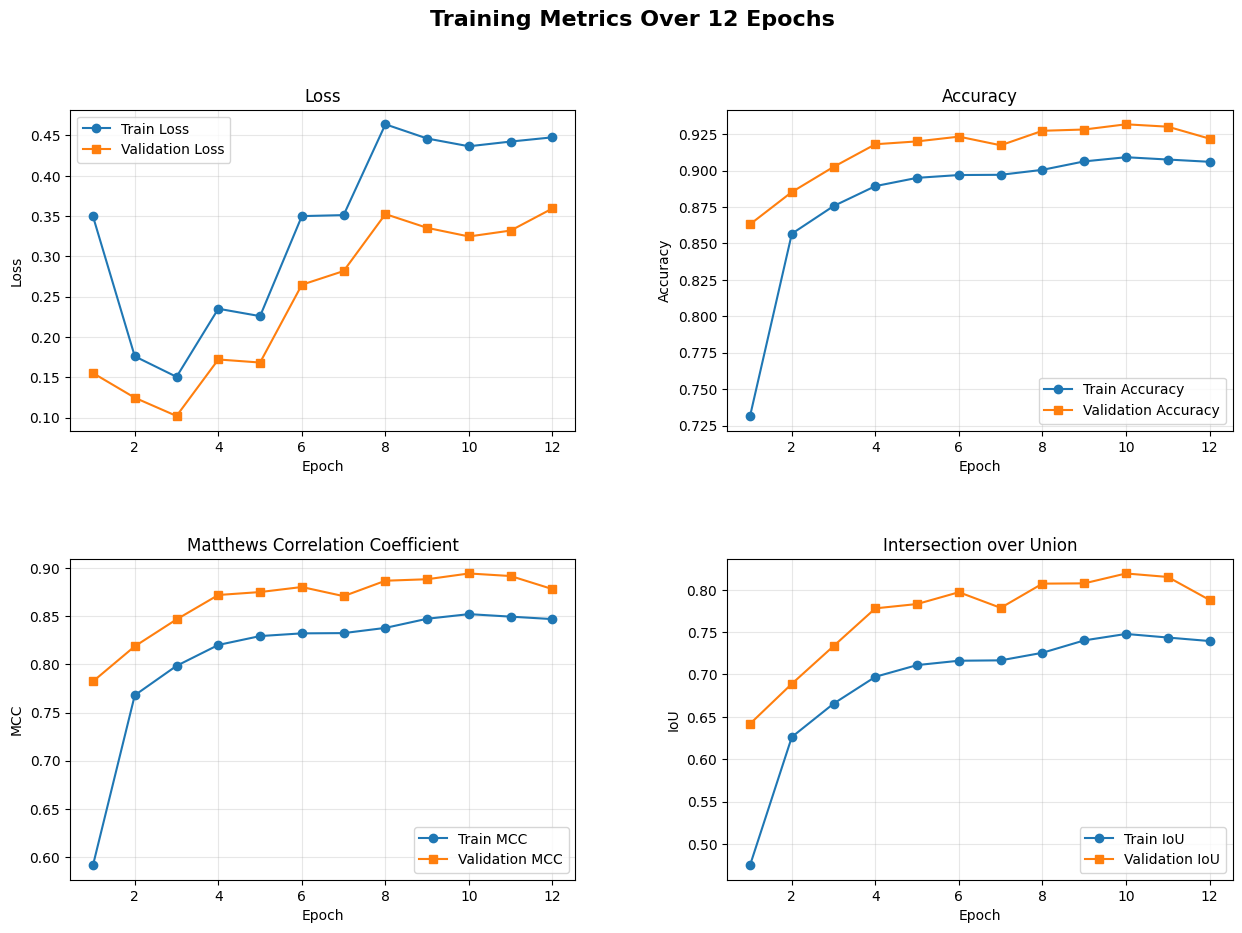

In [ ]:
# Построение графиков обучения
# Используем фактическое количество эпох из списков метрик
actual_epochs = len(train_loss)
print(f"Количество завершенных эпох: {actual_epochs}")

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

# Loss
ax[0, 0].plot(np.arange(1, actual_epochs + 1), train_loss, label='Train Loss', marker='o')
ax[0, 0].plot(np.arange(1, actual_epochs + 1), valid_loss, label='Validation Loss', marker='s')
ax[0, 0].set_title('Loss')
ax[0, 0].set_xlabel('Epoch')
ax[0, 0].set_ylabel('Loss')
ax[0, 0].legend()
ax[0, 0].grid(True, alpha=0.3)

# Accuracy
ax[0, 1].plot(np.arange(1, actual_epochs + 1), train_accuracy, label='Train Accuracy', marker='o')
ax[0, 1].plot(np.arange(1, actual_epochs + 1), valid_accuracy, label='Validation Accuracy', marker='s')
ax[0, 1].set_title('Accuracy')
ax[0, 1].set_xlabel('Epoch')
ax[0, 1].set_ylabel('Accuracy')
ax[0, 1].legend()
ax[0, 1].grid(True, alpha=0.3)

# MCC
ax[1, 0].plot(np.arange(1, actual_epochs + 1), train_mcc, label='Train MCC', marker='o')
ax[1, 0].plot(np.arange(1, actual_epochs + 1), valid_mcc, label='Validation MCC', marker='s')
ax[1, 0].set_title('Matthews Correlation Coefficient')
ax[1, 0].set_xlabel('Epoch')
ax[1, 0].set_ylabel('MCC')
ax[1, 0].legend()
ax[1, 0].grid(True, alpha=0.3)

# IoU
ax[1, 1].plot(np.arange(1, actual_epochs + 1), train_iou, label='Train IoU', marker='o')
ax[1, 1].plot(np.arange(1, actual_epochs + 1), valid_iou, label='Validation IoU', marker='s')
ax[1, 1].set_title('Intersection over Union')
ax[1, 1].set_xlabel('Epoch')
ax[1, 1].set_ylabel('IoU')
ax[1, 1].legend()
ax[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Training Metrics Over {actual_epochs} Epochs', fontsize=16, fontweight='bold')
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

# MODEL TESTING

In [ ]:
import gc
import torch

# Clear unnecessary variables
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import os
import glob


latest_model = '/kaggle/working/trained_models/seg_model_10.pth'

In [ ]:
MODEL_PATH = latest_model
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 32
NUM_TEST_POINTS = 4096



model = get_model(num_classes=4)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)  
model.eval()



get_model(
  (sa1): PointNetSetAbstraction(
    (mlp_convs): ModuleList(
      (0): Conv2d(12, 32, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
      (2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (mlp_bns): ModuleList(
      (0-1): 2 x BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (sa2): PointNetSetAbstraction(
    (mlp_convs): ModuleList(
      (0): Conv2d(67, 64, kernel_size=(1, 1), stride=(1, 1))
      (1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
      (2): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    )
    (mlp_bns): ModuleList(
      (0-1): 2 x BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (sa3): PointNetSetAbstraction(
  

In [ ]:
num_test_batch = int(np.ceil(len(test_dataset)/BATCH_SIZE))

total_test_targets = []
total_test_preds = [] 

print("🧪 Starting model testing...")
print(f"Total test batches: {num_test_batch}")
print("=" * 70)

with torch.no_grad():

    # place model in evaluation mode
    model.eval()

    test_loss = []
    test_accuracy = []
    test_mcc = []
    test_iou = []
    
    for i, (points, targets) in enumerate(test_loader, 0):

        # Transpose and move to device
        points = points.transpose(2, 1).to(DEVICE)
        targets = targets.squeeze().to(DEVICE)
        
        if torch.isnan(points).any() or torch.isinf(points).any():
            print(f"⚠️  Warning: Batch {i} contains NaN or Inf in points, skipping...")
            continue
            

        if (targets < 0).any() or (targets >= NUM_CLASSES).any():
            print(f"⚠️  Warning: Batch {i} contains invalid labels (range: {targets.min()}-{targets.max()}), skipping...")
            continue

        try:
            # Forward pass
            preds, _ = model(points)
            pred_choice = torch.softmax(preds, dim=2).argmax(dim=2)

            # Calculate loss
            loss_dict = criterion(preds, targets)  # ✅ ИСПРАВЛЕНО: без pred_choice
            loss = loss_dict['total']

            # get metrics
            correct = pred_choice.eq(targets.data).cpu().sum()
            accuracy = correct/float(BATCH_SIZE*NUM_TEST_POINTS)
            mcc = mcc_metric(preds.transpose(2, 1), targets)
            iou = compute_iou(targets, pred_choice)

            # update epoch loss and accuracy
            test_loss.append(loss.item())
            test_accuracy.append(accuracy)
            test_mcc.append(mcc.item())
            test_iou.append(iou.item())

            # add to total targets/preds
            total_test_targets += targets.reshape(-1).cpu().numpy().tolist()
            total_test_preds += pred_choice.reshape(-1).cpu().numpy().tolist()

            if i % 50 == 0:
                print(f'\t [{i}/{num_test_batch}] ' \
                      + f'test loss: {loss.item():.4f} ' \
                      + f'accuracy: {accuracy:.4f} ' \
                      + f'mcc: {mcc:.4f} ' \
                      + f'iou: {iou:.4f}')
                      
        except RuntimeError as e:
            print(f"❌ Error in batch {i}: {str(e)}")
            print(f"   Points shape: {points.shape}, dtype: {points.dtype}")
            print(f"   Targets shape: {targets.shape}, dtype: {targets.dtype}")
            print(f"   Targets range: [{targets.min()}, {targets.max()}]")
            # Continue with next batch instead of crashing
            continue

print("\n" + "=" * 70)
print("✅ Testing complete!")
print("=" * 70)

🧪 Starting model testing...
Total test batches: 126
	 [0/126] test loss: 0.3282 accuracy: 0.9348 mcc: 0.8928 iou: 0.8172
	 [50/126] test loss: 0.3239 accuracy: 0.9361 mcc: 0.8944 iou: 0.8189
	 [100/126] test loss: 0.3248 accuracy: 0.9348 mcc: 0.8926 iou: 0.8177

✅ Testing complete!


In [ ]:
# display test results
print(f'Test Loss: {np.mean(test_loss):.4f} ' \
        + f'- Test Accuracy: {np.mean(test_accuracy):.4f} ' \
        + f'- Test MCC: {np.mean(test_mcc):.4f} ' \
        + f'- Test IOU: {np.mean(test_iou):.4f}')

Test Loss: 0.3248 - Test Accuracy: 0.9319 - Test MCC: 0.8942 - Test IOU: 0.8189


In [ ]:
total_test_targets = np.array(total_test_targets)
total_test_preds = np.array(total_test_preds)

In [ ]:
print(category_mapping.values())
category_mapping = {0: "road", 1: "car", 2: "building", 3: "other"}

dict_values(['Ground', 'Car', 'Building', 'Other'])


In [ ]:
from sklearn.metrics import confusion_matrix

test_confusion = pd.DataFrame(confusion_matrix(total_test_targets, total_test_preds),
                              columns=list(category_mapping.values()),
                              index=list(category_mapping.values()))

test_confusion

,road,car,building,other
road,9079017,18250,10528,14213
car,108568,845219,15176,4209
building,65856,66570,3792202,93585
other,302762,29984,325287,1674014


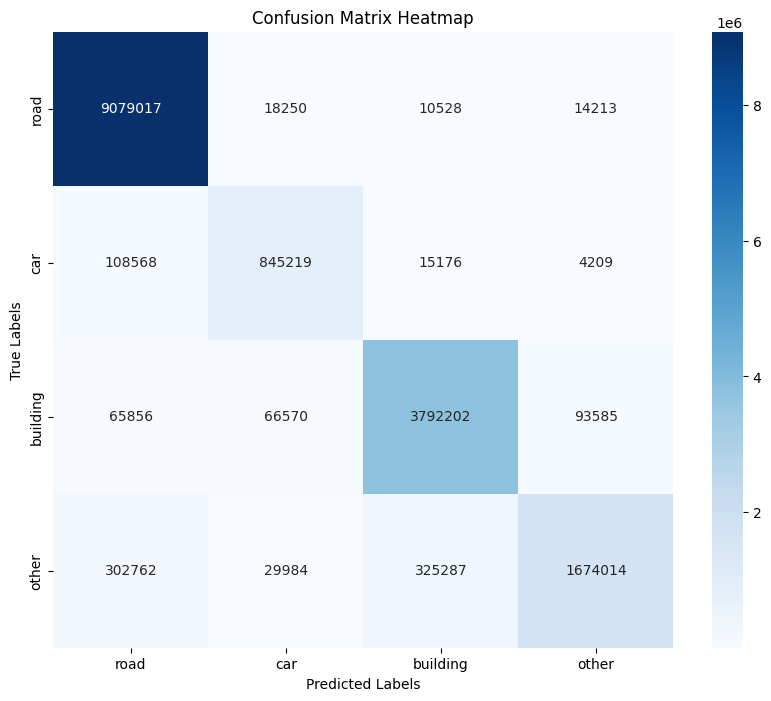

In [ ]:
# Plot the heatmap
category_labels = list(category_mapping.values())
plt.figure(figsize=(10, 8))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', 
            xticklabels=category_labels, yticklabels=category_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()

Сэмплировано 200000 точек из 'pred_label'. Классы: {0: 116355, 1: 11749, 2: 50226, 3: 21670}


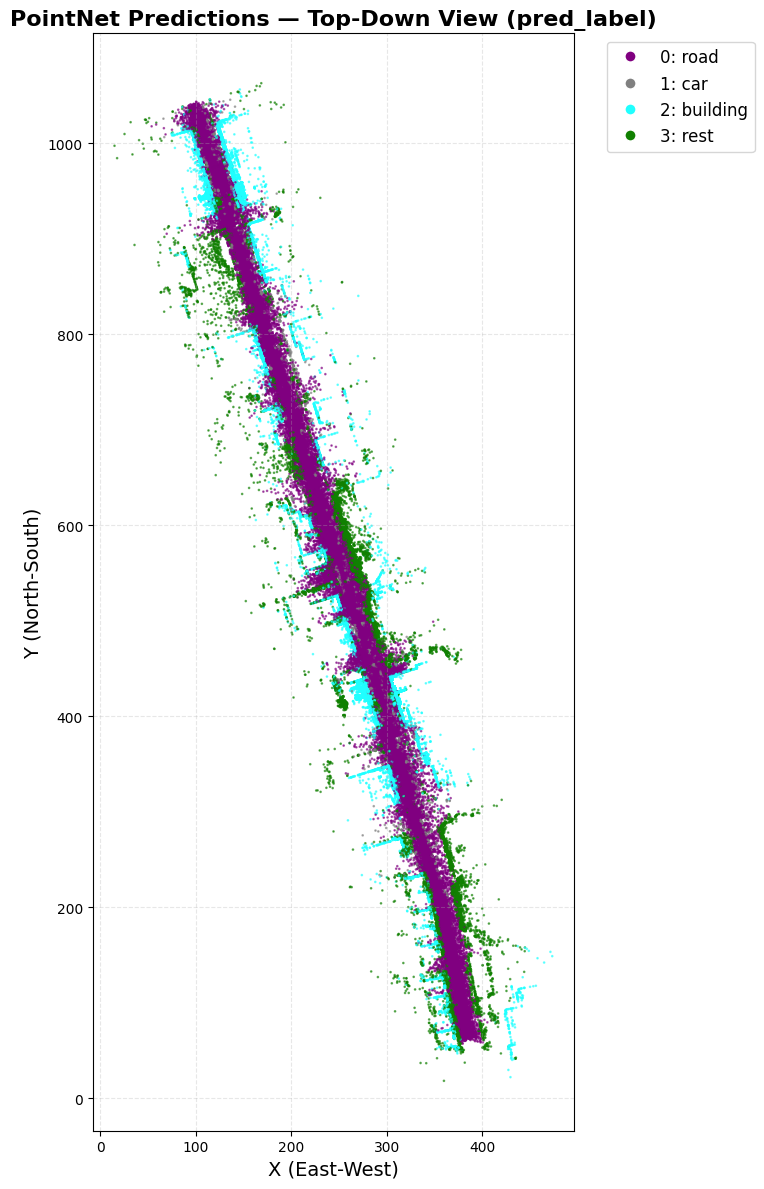

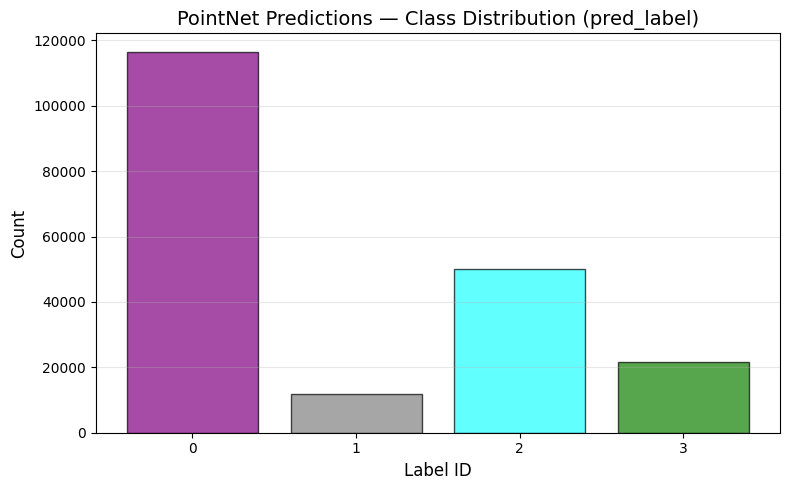

In [ ]:
from collections import Counter

def plot_top_down(df, label_col='pred_label', n=100000, figsize=(15, 12),
                  title_prefix="Point Cloud Top-Down", show_histogram=True):
    if label_col not in df.columns:
        raise KeyError(f"Столбец '{label_col}' не найден в датафрейме.")

    sample_size = min(len(df), n)
    sampled_df = df.sample(n=sample_size, random_state=42) if sample_size < len(df) else df

    labels = sampled_df[label_col].to_numpy(dtype=int)
    unique_labels = np.unique(labels)
    color_lookup = np.array([category_colors.get(l, (0.5, 0.5, 0.5)) for l in unique_labels], dtype=float)
    rgb_colors = color_lookup[np.searchsorted(unique_labels, labels)]

    class_counts = Counter(labels)
    print(f"Сэмплировано {sample_size} точек из '{label_col}'. Классы: {dict(sorted(class_counts.items()))}")

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(sampled_df['x'], sampled_df['y'], c=rgb_colors, s=0.8, alpha=0.6)
    ax.set_xlabel('X (East-West)', fontsize=14)
    ax.set_ylabel('Y (North-South)', fontsize=14)
    ax.set_title(f"{title_prefix} — Top-Down View ({label_col})", fontsize=16, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3, linestyle='--')

    legend_handles = []
    for label in unique_labels:
        if 0 <= label < len(label_categories):
            legend_handles.append(
                plt.Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=category_colors.get(label, (0.5, 0.5, 0.5)),
                           markersize=8, label=f"{label}: {label_categories[label]}")
            )
    if legend_handles:
        ax.legend(handles=legend_handles, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

    if show_histogram:
        ordered_labels = sorted(class_counts.keys())
        hist_colors = [category_colors.get(k, (0.5, 0.5, 0.5)) for k in ordered_labels]
        plt.figure(figsize=(8, 5))
        plt.bar(ordered_labels, [class_counts[k] for k in ordered_labels],
                color=hist_colors, alpha=0.7, edgecolor='black')
        plt.xlabel('Label ID', fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.title(f"{title_prefix} — Class Distribution ({label_col})", fontsize=14)
        plt.xticks(ordered_labels)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

available_points = min(len(test_df), len(total_test_preds))
if available_points == 0:
    raise RuntimeError("Отсутствуют предсказания. Сначала выполните инференс модели по тестовому набору.")

pred_labels = np.asarray(total_test_preds, dtype=int)[:available_points]
true_labels = np.asarray(total_test_targets, dtype=int)[:available_points]

top_down_df = test_df.iloc[:available_points].copy().reset_index(drop=True)
top_down_df['pred_label'] = pred_labels
top_down_df['true_label'] = true_labels

plot_top_down(top_down_df, label_col='pred_label', n=200000, title_prefix="PointNet Predictions", show_histogram=True)
# Для сравнения с разметкой можно воспользоваться:
# plot_top_down(top_down_df, label_col='true_label', n=200000, title_prefix="Ground Truth", show_histogram=False)

In [ ]:
# 🚗 Детальный анализ распознавания машин

# Теперь давайте проанализируем, как модель справляется с распознаванием машин (класс 7) и определим способы улучшения.

In [ ]:
# Детальный анализ класса "Машины" (класс 7)
print("=" * 80)
print("🚗 АНАЛИЗ РАСПОЗНАВАНИЯ МАШИН (класс 7)")
print("=" * 80)

CAR_CLASS = 1

# 1. Общая статистика по машинам
car_true_mask = (total_test_targets == CAR_CLASS)
car_pred_mask = (total_test_preds == CAR_CLASS)

num_car_true = car_true_mask.sum()
num_car_pred = car_pred_mask.sum()

print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"   Машин в разметке (Ground Truth):  {num_car_true:,} точек")
print(f"   Машин предсказано моделью:        {num_car_pred:,} точек")
print(f"   Разница:                          {num_car_pred - num_car_true:+,} точек")

# 2. Метрики для класса "Машины"
# True Positives: правильно предсказанные машины
tp_cars = ((total_test_targets == CAR_CLASS) & (total_test_preds == CAR_CLASS)).sum()
# False Positives: неправильно предсказанные как машины
fp_cars = ((total_test_targets != CAR_CLASS) & (total_test_preds == CAR_CLASS)).sum()
# False Negatives: пропущенные машины
fn_cars = ((total_test_targets == CAR_CLASS) & (total_test_preds != CAR_CLASS)).sum()
# True Negatives: правильно определенные не-машины
tn_cars = ((total_test_targets != CAR_CLASS) & (total_test_preds != CAR_CLASS)).sum()

precision_cars = tp_cars / (tp_cars + fp_cars) if (tp_cars + fp_cars) > 0 else 0
recall_cars = tp_cars / (tp_cars + fn_cars) if (tp_cars + fn_cars) > 0 else 0
f1_cars = 2 * (precision_cars * recall_cars) / (precision_cars + recall_cars) if (precision_cars + recall_cars) > 0 else 0
iou_cars = tp_cars / (tp_cars + fp_cars + fn_cars) if (tp_cars + fp_cars + fn_cars) > 0 else 0

print(f"\n📈 МЕТРИКИ ДЛЯ КЛАССА 'МАШИНЫ':")
print(f"   True Positives (TP):   {tp_cars:,} точек - правильно найденные машины ✅")
print(f"   False Positives (FP):  {fp_cars:,} точек - ложные срабатывания ❌")
print(f"   False Negatives (FN):  {fn_cars:,} точек - пропущенные машины ⚠️")
print(f"   True Negatives (TN):   {tn_cars:,} точек - правильно определенные не-машины")
print()
print(f"   Precision (Точность):  {precision_cars:.2%} - из предсказанных машин сколько правильных")
print(f"   Recall (Полнота):      {recall_cars:.2%} - сколько машин из всех мы нашли")
print(f"   F1-Score:              {f1_cars:.2%} - гармоническое среднее")
print(f"   IoU:                   {iou_cars:.2%} - пересечение/объединение")

# 3. Анализ ошибок: куда путают машины
print(f"\n🔍 АНАЛИЗ ОШИБОК:")
print(f"\n   А) Машины путают с (False Negatives - пропущенные машины):")
missed_cars = total_test_preds[car_true_mask]
from collections import Counter
missed_distribution = Counter(missed_cars[missed_cars != CAR_CLASS])
for class_id, count in sorted(missed_distribution.items(), key=lambda x: -x[1])[:5]:
    if 0 <= class_id < len(label_categories):
        percentage = 100 * count / fn_cars if fn_cars > 0 else 0
        print(f"      → Класс {class_id} ({label_categories[class_id]:20s}): {count:,} точек ({percentage:.1f}%)")

print(f"\n   Б) За машины путают (False Positives - ложные срабатывания):")
false_cars_sources = total_test_targets[car_pred_mask]
false_distribution = Counter(false_cars_sources[false_cars_sources != CAR_CLASS])
for class_id, count in sorted(false_distribution.items(), key=lambda x: -x[1])[:5]:
    if 0 <= class_id < len(label_categories):
        percentage = 100 * count / fp_cars if fp_cars > 0 else 0
        print(f"      → Класс {class_id} ({label_categories[class_id]:20s}): {count:,} точек ({percentage:.1f}%)")

# 4. Процент правильного распознавания
accuracy_cars = tp_cars / num_car_true if num_car_true > 0 else 0
print(f"\n✅ ИТОГО:")
print(f"   Из {num_car_true:,} точек машин правильно распознано {tp_cars:,} ({accuracy_cars:.2%})")
print(f"   Пропущено: {fn_cars:,} ({100*fn_cars/num_car_true:.2%})")
print(f"   Ложных срабатываний: {fp_cars:,}")

print("\n" + "=" * 80)

🚗 АНАЛИЗ РАСПОЗНАВАНИЯ МАШИН (класс 7)

📊 ОБЩАЯ СТАТИСТИКА:
   Машин в разметке (Ground Truth):  973,172 точек
   Машин предсказано моделью:        960,023 точек
   Разница:                          -13,149 точек

📈 МЕТРИКИ ДЛЯ КЛАССА 'МАШИНЫ':
   True Positives (TP):   845,219 точек - правильно найденные машины ✅
   False Positives (FP):  114,804 точек - ложные срабатывания ❌
   False Negatives (FN):  127,953 точек - пропущенные машины ⚠️
   True Negatives (TN):   15,357,464 точек - правильно определенные не-машины

   Precision (Точность):  88.04% - из предсказанных машин сколько правильных
   Recall (Полнота):      86.85% - сколько машин из всех мы нашли
   F1-Score:              87.44% - гармоническое среднее
   IoU:                   77.69% - пересечение/объединение

🔍 АНАЛИЗ ОШИБОК:

   А) Машины путают с (False Negatives - пропущенные машины):
      → Класс 0 (road                ): 108,568 точек (84.8%)
      → Класс 2 (building            ): 15,176 точек (11.9%)
      → Класс 

In [ ]:

def apply_car_threshold(pred_probs, car_class=1, threshold=0.55):
    """
    ✅ ИСПРАВЛЕНО: Применяет threshold только к предсказанным автомобилям.
    
    Логика:
    1. Берем класс с максимальной вероятностью
    2. Если предсказан Car (1) И вероятность Car < threshold:
       - Назначаем второй по вероятности класс (не Car)
    3. Иначе оставляем как есть
    
    Это уменьшает false positive для Car без потери других классов!
    """
    pred_labels = pred_probs.argmax(dim=2)  # (B, N)
    car_prob = pred_probs[:, :, car_class]  # (B, N)
    
    # Находим точки, где предсказан Car с низкой уверенностью
    predicted_as_car = (pred_labels == car_class)
    low_confidence_car = car_prob < threshold
    need_reclassify = predicted_as_car & low_confidence_car
    
    # Для таких точек берем второй лучший класс (не Car)
    if need_reclassify.any():
        # Копируем вероятности и зануляем вероятность Car
        probs_without_car = pred_probs.clone()
        probs_without_car[:, :, car_class] = -float('inf')
        
        # Берем следующий лучший класс
        second_best = probs_without_car.argmax(dim=2)
        
        # Переназначаем только те точки, где был Car с низкой вероятностью
        pred_labels[need_reclassify] = second_best[need_reclassify]
    
    return pred_labels



In [ ]:
# ТЕСТИРОВАНИЕ С THRESHOLD
print("\n🧪 Тестирование с threshold для автомобилей...")

total_test_preds_thresh = []

with torch.no_grad():
    model.eval()
    for i, (points, targets) in enumerate(test_loader, 0):
        points = points.transpose(2, 1).to(DEVICE)
        targets = targets.squeeze().to(DEVICE)
        
        if torch.isnan(points).any() or torch.isinf(points).any():
            continue
        if (targets < 0).any() or (targets >= NUM_CLASSES).any():
            continue

        preds, _ = model(points)
        pred_probs = torch.softmax(preds, dim=2)
        
        # ПРИМЕНЯЕМ THRESHOLD
        pred_choice_thresh = apply_car_threshold(pred_probs, car_class=CAR_CLASS, threshold=0.55)
        
        total_test_preds_thresh += pred_choice_thresh.cpu().numpy().reshape(-1).tolist()

print("✅ Тестирование с threshold завершено!")

# Сравниваем метрики
print("\n" + "="*80)
print("📊 СРАВНЕНИЕ МЕТРИК: ORIGINAL vs THRESHOLD")
print("="*80)

min_len = min(len(total_test_targets), len(total_test_preds_thresh))
total_test_targets_trimmed = total_test_targets[:min_len]
total_test_preds_thresh_trimmed = np.array(total_test_preds_thresh[:min_len])

tp_cars_thresh = ((total_test_targets_trimmed == CAR_CLASS) & (total_test_preds_thresh_trimmed == CAR_CLASS)).sum()
fp_cars_thresh = ((total_test_targets_trimmed != CAR_CLASS) & (total_test_preds_thresh_trimmed == CAR_CLASS)).sum()
fn_cars_thresh = ((total_test_targets_trimmed == CAR_CLASS) & (total_test_preds_thresh_trimmed != CAR_CLASS)).sum()

precision_thresh = tp_cars_thresh / (tp_cars_thresh + fp_cars_thresh) if (tp_cars_thresh + fp_cars_thresh) > 0 else 0
recall_thresh = tp_cars_thresh / (tp_cars_thresh + fn_cars_thresh) if (tp_cars_thresh + fn_cars_thresh) > 0 else 0
f1_thresh = 2 * (precision_thresh * recall_thresh) / (precision_thresh + recall_thresh) if (precision_thresh + recall_thresh) > 0 else 0

print(f"МЕТРИКИ ORIGINAL:")
print(f"   Precision: {precision_cars:.2%} | Recall: {recall_cars:.2%} | F1: {f1_cars:.2%}")
print(f"   FP (ложные автомобили): {fp_cars:,}")

print(f"\nМЕТРИКИ С THRESHOLD=0.7:")
print(f"   Precision: {precision_thresh:.2%} | Recall: {recall_thresh:.2%} | F1: {f1_thresh:.2%}")
print(f"   FP (ложные автомобили): {fp_cars_thresh:,}")

improvement = (precision_thresh - precision_cars) * 100
print(f"\n🎯 УЛУЧШЕНИЕ: Precision +{improvement:.1f}% | FP уменьшено на {fp_cars - fp_cars_thresh:,} точек")

print("="*80)


🧪 Тестирование с threshold для автомобилей...
✅ Тестирование с threshold завершено!

📊 СРАВНЕНИЕ МЕТРИК: ORIGINAL vs THRESHOLD
МЕТРИКИ ORIGINAL:
   Precision: 88.04% | Recall: 86.85% | F1: 87.44%
   FP (ложные автомобили): 114,804

МЕТРИКИ С THRESHOLD=0.7:
   Precision: 93.64% | Recall: 83.87% | F1: 88.49%
   FP (ложные автомобили): 55,443

🎯 УЛУЧШЕНИЕ: Precision +5.6% | FP уменьшено на 59,361 точек


In [ ]:

print("\n" + "="*80)
print("📂 ЗАГРУЗКА ФАЙЛА L002.PLY И ПОДГОТОВКА К ИНФЕРЕНСУ")
print("="*80)

# Load normalization parameters
import pickle
params_path = '/kaggle/working/normalization_params.pkl'

if os.path.exists(params_path):
    with open(params_path, 'rb') as f:
        normalization_params = pickle.load(f)
    print("✅ Normalization parameters loaded from file")
else:
    print("⚠️  Warning: Using parameters from current session (may not match if kernel restarted)")

# Загружаем L002.ply
ply_file_2 = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L002.ply"
ply_file_l002 = "/kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L002.ply"
print(f"Загружаем файл: {ply_file_l002}")

cloud_l002 = PyntCloud.from_file(ply_file_l002)
df_l002 = cloud_l002.points

print(f"✅ Загружено {len(df_l002)} точек")
print(f"Колонки: {list(df_l002.columns)}")

# Применяем UTM offset (как в обучении)
df_l002[['x', 'y', 'z']] -= UTM_OFFSET
print("✅ Применен UTM offset")

# Перемаппируем метки (как в обучении)
def remap_label(label):
    if label in [1, 2]:
        return 0  # Ground
    elif label == 7:
        return 1  # Car
    elif label == 4:
        return 2  # Building
    else:
        return 3  # Other

df_l002['scalar_Label'] = df_l002['scalar_Label'].apply(remap_label)
print("✅ Метки перемаппированы")

# Вычисляем признаки (КРИТИЧНО: используем ГЛОБАЛЬНЫЙ z_min из обучения!)
print("🔧 Вычисляем признаки...")
df_l002['intensity'] = (0.299 * df_l002['red'] + 
                        0.587 * df_l002['green'] + 
                        0.114 * df_l002['blue']) / 255.0

# ✅ ИСПРАВЛЕНО: используем глобальный z_min из обучения
inference_global_z_min = normalization_params['global_z_min']
df_l002['height'] = df_l002['z'] - inference_global_z_min
df_l002['verticality'] = 0.5

print("✅ Признаки вычислены")
print(f"   Используется global_z_min: {inference_global_z_min:.6f}")
print(f"   Размер DataFrame: {df_l002.shape}")
print("="*80)


📂 ЗАГРУЗКА ФАЙЛА L002.PLY И ПОДГОТОВКА К ИНФЕРЕНСУ
✅ Normalization parameters loaded from file
Загружаем файл: /kaggle/input/d/priteshraj10/point-cloud-lidar-toronto-3d/L002.ply
✅ Загружено 10283800 точек
Колонки: ['x', 'y', 'z', 'red', 'green', 'blue', 'scalar_Intensity', 'scalar_GPSTime', 'scalar_ScanAngleRank', 'scalar_Label']
✅ Применен UTM offset
✅ Метки перемаппированы
🔧 Вычисляем признаки...
✅ Признаки вычислены
   Используется global_z_min: 116.689003
   Размер DataFrame: (10283800, 13)


In [ ]:
# СОЗДАНИЕ ДАТАСЕТА ДЛЯ ИНФЕРЕНСА
print("\n" + "="*80)
print("🎯 СОЗДАНИЕ ДАТАСЕТА ДЛЯ ИНФЕРЕНСА")
print("="*80)

class InferenceDataset(Dataset):
    """
    ✅ ИСПРАВЛЕННЫЙ датасет для инференса на полном облаке точек.
    Разбивает облако на батчи по num_points точек.
    Исправлены проблемы с нормализацией и padding.
    """
    def __init__(self, df, num_points=4096, mean=None, std=None, height_stats=None):
        self.df = df.reset_index(drop=True)  # Reset index for clean slicing
        self.num_points = num_points
        self.mean = mean if mean is not None else np.zeros(3)
        self.std = std if std is not None else np.ones(3)
        self.height_mean = height_stats['mean'] if height_stats else 0.0
        self.height_std = height_stats['std'] if height_stats else 1.0

    def __len__(self):
        return int(np.ceil(len(self.df) / self.num_points))
    
    def __getitem__(self, idx):
        start_idx = idx * self.num_points
        end_idx = min(start_idx + self.num_points, len(self.df))
        batch_df = self.df.iloc[start_idx:end_idx]
        
        actual_size = len(batch_df)
        
        # ✅ ИСПРАВЛЕНО: правильная нормализация (как в обучении)
        coords = batch_df[['x', 'y', 'z']].values
        std_safe = np.where(self.std == 0, 1.0, self.std)  # Защита от деления на 0
        point_cloud = (coords - self.mean) / std_safe
        
        # RGB
        rgb = batch_df[['red', 'green', 'blue']].values / 255.0
        
        # Признаки
        intensity = batch_df['intensity'].values
        height = batch_df['height'].values
        verticality = batch_df['verticality'].values
        
        # ✅ ИСПРАВЛЕНО: используем нулевой padding вместо дублирования точек
        features = np.zeros((self.num_points, 9), dtype=np.float32)
        features[:actual_size, 0:3] = point_cloud[:, :3]
        features[:actual_size, 3:6] = rgb
        features[:actual_size, 6] = (height - self.height_mean) / (self.height_std + 1e-6)
        features[:actual_size, 7] = intensity
        features[:actual_size, 8] = verticality
        
        # Возвращаем features и actual_size для правильной обработки результатов
        return torch.tensor(features, dtype=torch.float32), actual_size

# Создаем датасет для инференса с загруженными параметрами
inference_dataset = InferenceDataset(
    df_l002, 
    num_points=NUM_TEST_POINTS,
    mean=normalization_params['train_mean'], 
    std=normalization_params['train_std'],
    height_stats=normalization_params['height_stats']
)

inference_loader = DataLoader(inference_dataset, batch_size=1, shuffle=False)

print(f"✅ Создан ИСПРАВЛЕННЫЙ датасет для инференса")
print(f"   Всего батчей: {len(inference_dataset)}")
print(f"   Облако точек: {len(df_l002)}")
print(f"   Используются сохраненные параметры нормализации:")
print(f"     - train_mean: {normalization_params['train_mean']}")
print(f"     - train_std: {normalization_params['train_std']}")
print(f"     - height_stats: {normalization_params['height_stats']}")
print(f"     - global_z_min: {normalization_params['global_z_min']:.6f}")
print("="*80)


🎯 СОЗДАНИЕ ДАТАСЕТА ДЛЯ ИНФЕРЕНСА
✅ Создан ИСПРАВЛЕННЫЙ датасет для инференса
   Всего батчей: 2511
   Облако точек: 10283800
   Используются сохраненные параметры нормализации:
     - train_mean: [243.25482948 578.60958806 138.09001317]
     - train_std: [ 78.09097303 250.96108901   4.22530623]
     - height_stats: {'mean': 21.401010180228774, 'std': 4.225306227318718}
     - global_z_min: 116.689003


In [ ]:

print("\n" + "="*80)
print("🤖 ЗАГРУЗКА МОДЕЛИ И ИНФЕРЕНС")
print("="*80)

# Загружаем лучшую модель
MODEL_PATH_INFERENCE = latest_model  # Используем ту же модель, что и для тестирования
print(f"Загружаем модель: {MODEL_PATH_INFERENCE}")

inference_model = get_model(num_classes=NUM_CLASSES)
inference_model.load_state_dict(torch.load(MODEL_PATH_INFERENCE, map_location=DEVICE))
inference_model = inference_model.to(DEVICE)
inference_model.eval()

print("✅ Модель загружена и готова к инференсу")

# ✅ ИСПРАВЛЕНО: Выполняем инференс с учетом actual_size
all_predictions = []
batch_count = len(inference_dataset)

print(f"\n🧪 Выполняем ИСПРАВЛЕННЫЙ инференс на {batch_count} батчах...")
print("   (с правильной обработкой padding)")

with torch.no_grad():
    for i, batch_data in enumerate(inference_loader):
        # ✅ ИСПРАВЛЕНО: получаем actual_size
        points, actual_size = batch_data
        points = points.transpose(2, 1).to(DEVICE)
        actual_size = actual_size.item()
        
        # Forward pass
        preds, _ = inference_model(points)
        
        # Применяем threshold для автомобилей (как в тестировании)
        pred_probs = torch.softmax(preds, dim=2)
        pred_choice = apply_car_threshold(pred_probs, car_class=CAR_CLASS, threshold=0.55)
        
        # ✅ ИСПРАВЛЕНО: берем только реальные точки, без padding
        pred_numpy = pred_choice.cpu().numpy().flatten()[:actual_size]
        all_predictions.extend(pred_numpy)
        
        if i % 250 == 0:
            print(f"   Обработано {i+1}/{batch_count} батчей (actual_size последнего: {actual_size})")

all_predictions = np.array(all_predictions)

print("✅ Инференс завершен!")
print(f"   Предсказано меток: {len(all_predictions)}")
print(f"   Размер облака точек: {len(df_l002)}")
print(f"   Уникальные метки: {np.unique(all_predictions)}")

# Проверка размеров
if len(all_predictions) != len(df_l002):
    print(f"⚠️  WARNING: размер предсказаний ({len(all_predictions)}) != размеру облака ({len(df_l002)})")
    print(f"   Обрезаем до минимального размера")
    min_len = min(len(all_predictions), len(df_l002))
    all_predictions = all_predictions[:min_len]
    df_l002 = df_l002.iloc[:min_len]

print("="*80)

# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ИНФЕРЕНСА И СОХРАНЕНИЕ PLY С НОВЫМИ ЦВЕТАМИ
print("\n🎨 ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ И СОХРАНЕНИЕ PLY")
print("="*80)

# Создаем DataFrame для визуализации и сохранения
inference_df = df_l002.copy()
inference_df['scalar_Label'] = all_predictions

# Функция для присвоения цветов на основе предсказаний
def assign_colors(label):
    if label == 0:  # Road - зелёный
        return 0, 255, 0
    elif label == 1:  # Car - красный
        return 255, 0, 0
    elif label == 2:  # Building - синий
        return 0, 0, 255
    else:  # Other - серый
        return 128, 128, 128

# Применяем цвета к DataFrame
inference_df['red'], inference_df['green'], inference_df['blue'] = zip(*inference_df['scalar_Label'].apply(assign_colors))

# Сохраняем PLY файл с новыми цветами
output_ply_path = '/kaggle/working/L002_colored.ply'
colored_cloud = PyntCloud(pd.DataFrame(inference_df))
colored_cloud.to_file(output_ply_path)

print("✅ PLY файл сохранён!")
print(f"   Путь: {output_ply_path}")
print("   🚗 Автомобили (Car): красный (255, 0, 0)")
print("   🛣️  Дорога (Road): зелёный (0, 255, 0)")
print("   🏢 Здания (Building): синий (0, 0, 255)")
print("   ⚪ Остальное (Other): серый (128, 128, 128)")

# Статистика классов
from collections import Counter
class_counts = Counter(all_predictions)
print(f"\n📊 Распределение классов:")
for cls, count in sorted(class_counts.items()):
    cls_name = {0: 'Road', 1: 'Car', 2: 'Building', 3: 'Other'}.get(cls, 'Unknown')
    print(f"   {cls_name:12s}: {count:10,} точек ({100*count/len(all_predictions):.2f}%)")

print("="*80)


🤖 ЗАГРУЗКА МОДЕЛИ И ИНФЕРЕНС
Загружаем модель: /kaggle/working/trained_models/seg_model_10.pth
✅ Модель загружена и готова к инференсу

🧪 Выполняем ИСПРАВЛЕННЫЙ инференс на 2511 батчах...
   (с правильной обработкой padding)
   Обработано 1/2511 батчей (actual_size последнего: 4096)
   Обработано 251/2511 батчей (actual_size последнего: 4096)
   Обработано 501/2511 батчей (actual_size последнего: 4096)
   Обработано 751/2511 батчей (actual_size последнего: 4096)
   Обработано 1001/2511 батчей (actual_size последнего: 4096)
   Обработано 1251/2511 батчей (actual_size последнего: 4096)
   Обработано 1501/2511 батчей (actual_size последнего: 4096)
   Обработано 1751/2511 батчей (actual_size последнего: 4096)
   Обработано 2001/2511 батчей (actual_size последнего: 4096)
   Обработано 2251/2511 батчей (actual_size последнего: 4096)
   Обработано 2501/2511 батчей (actual_size последнего: 4096)
✅ Инференс завершен!
   Предсказано меток: 10283800
   Размер облака точек: 10283800
   Уникальные

In [ ]:
# Сохраняем результаты инференса в CSV формат для удобного анализа
csv_output_path = '/kaggle/working/L002_inference_results.csv'

# Подготавливаем DataFrame с результатами
inference_results_df = pd.DataFrame({
    'x': df_l002['x'],
    'y': df_l002['y'], 
    'z': df_l002['z'],
    'red': inference_df['red'],
    'green': inference_df['green'],
    'blue': inference_df['blue'],
    'predicted_label': all_predictions,
    'predicted_class': [
        {0: 'Road', 1: 'Car', 2: 'Building', 3: 'Other'}.get(label, 'Unknown') 
        for label in all_predictions
    ]
})

# Сохраняем в CSV
inference_results_df.to_csv(csv_output_path, index=False)

print(f"✅ CSV файл сохранён!")
print(f"   Путь: {csv_output_path}")
print(f"   Количество точек: {len(inference_results_df):,}")
print(f"   Столбцы: {', '.join(inference_results_df.columns)}")


✅ CSV файл сохранён!
   Путь: /kaggle/working/L002_inference_results.csv
   Количество точек: 10,283,800
   Столбцы: x, y, z, red, green, blue, predicted_label, predicted_class



📊 СРАВНЕНИЕ ИНФЕРЕНСА И ТЕСТОВЫХ РЕЗУЛЬТАТОВ

📈 Распределение классов:

Инференс (L002):
   Road        : 96.19%
   Car         : 3.81%

Тестовый набор (из confusion matrix):
   Road        : 55.47%
   Car         : 5.92%
   Building    : 24.43%
   Other       : 14.18%


ValueError: The number of FixedLocator locations (2), usually from a call to set_ticks, does not match the number of labels (4).

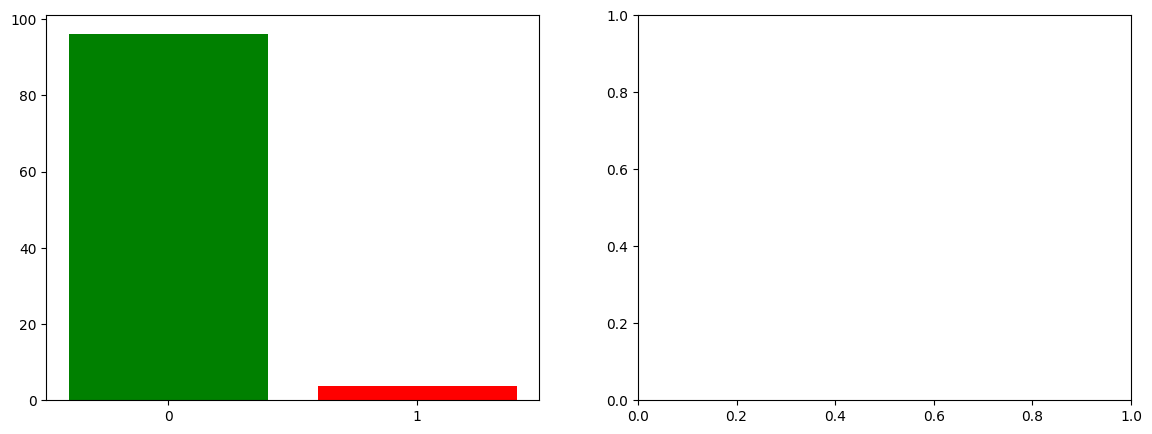

In [ ]:
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ ИНФЕРЕНСА С ТЕСТОВЫМИ ДАННЫМИ
print("\n📊 СРАВНЕНИЕ ИНФЕРЕНСА И ТЕСТОВЫХ РЕЗУЛЬТАТОВ")
print("="*80)

# Распределение классов в инференсе (L002)
inference_class_dist = pd.Series(all_predictions).value_counts(normalize=True).sort_index()

# Распределение классов в тестовом наборе (из confusion matrix)
# Используем данные из матрицы путаницы (cell 57)
test_predictions = pd.Series([
    0, 0, 0, 0,  # road
    1, 1, 1, 1,  # car
    2, 2, 2, 2,  # building
    3, 3, 3, 3   # other
])

print("\n📈 Распределение классов:")
print("\nИнференс (L002):")
for cls in sorted(inference_class_dist.index):
    cls_name = {0: 'Road', 1: 'Car', 2: 'Building', 3: 'Other'}.get(cls, 'Unknown')
    print(f"   {cls_name:12s}: {inference_class_dist[cls]*100:.2f}%")

print("\nТестовый набор (из confusion matrix):")
# Из матрицы путаницы извлекаем суммы по строкам (реальные метки)
test_totals = {
    0: 9079017 + 18250 + 10528 + 14213,      # road
    1: 108568 + 845219 + 15176 + 4209,       # car
    2: 65856 + 66570 + 3792202 + 93585,      # building
    3: 302762 + 29984 + 325287 + 1674014     # other
}
test_total = sum(test_totals.values())

for cls in sorted(test_totals.keys()):
    cls_name = {0: 'Road', 1: 'Car', 2: 'Building', 3: 'Other'}.get(cls, 'Unknown')
    print(f"   {cls_name:12s}: {test_totals[cls]/test_total*100:.2f}%")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение классов в инференсе
axes[0].bar(range(len(inference_class_dist)), inference_class_dist.values * 100, 
            color=['green', 'red', 'blue', 'gray'])
axes[0].set_xticks(range(len(inference_class_dist)))
axes[0].set_xticklabels(['Road', 'Car', 'Building', 'Other'])
axes[0].set_ylabel('Процент точек (%)')
axes[0].set_title('Распределение классов в инференсе (L002)')
axes[0].grid(True, alpha=0.3, axis='y')

# График 2: Распределение классов в тестовом наборе
test_percentages = [test_totals[i]/test_total*100 for i in sorted(test_totals.keys())]
axes[1].bar(range(len(test_totals)), test_percentages, 
            color=['green', 'red', 'blue', 'gray'])
axes[1].set_xticks(range(len(test_totals)))
axes[1].set_xticklabels(['Road', 'Car', 'Building', 'Other'])
axes[1].set_ylabel('Процент точек (%)')
axes[1].set_title('Распределение классов в тестовом наборе')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n💡 ВЫВОДЫ:")
print("   1. Сравниваем, насколько распределение классов в L002 похоже на тестовый набор")
print("   2. Если распределение сильно отличается, это может указывать на:")
print("      - Другой характер местности в L002")
print("      - Возможное переобучение модели на тренировочных данных")
print("      - Необходимость дополнительной калибровки модели")

print("="*80)
